## Load packages and define functions

In [2]:
import pandas as pd 
import pyam
import matplotlib.pyplot as plt
import pandas_indexing as pix
from pandas_indexing import isin, ismatch
import numpy as np

import os
from pathlib import Path

from fuzzywuzzy import fuzz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import data_shepherd as ds
from data_shepherd import utils
import datatoolbox as dt

<IPython.core.display.Javascript object>

In [3]:
def elec(tech=None):
    if not tech is None:
        return f'Secondary Energy|Electricity|{tech}'
    else:
        return 'Secondary Energy|Electricity'

In [4]:
IKEA_ISOS = ["DEU","POL","BRA","MEX","KEN","MAR","MOZ",
             "NGA","SEN","ZAF","USA","NAM","DZA","TUR","SAU",
             "ARE","BGD","IND","IDN","PAK","VNM","GBR","AUS","CHN","JPN"]

IKEA_ISOS.sort()

## Load data

In [5]:
BOX_MOUNT_PATH = Path("~/Library/CloudStorage/Box-Box").expanduser()
if not BOX_MOUNT_PATH.is_dir():
    BOX_MOUNT_PATH = Path("~/Box").expanduser()

In [6]:
DSCALE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Downscaling/"
    "DSCALE"
)

DSCALE_PATH: os.PathLike = BOX_MOUNT_PATH / DSCALE_PATH

In [7]:
REMIND_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP1 - Updating global 1.5°C Pathways/"
    "1 - PIK/"
    "Scenario Data/"
    "SUBMITTED_SCENARIOS_August2025/"

)

REMIND_PATH: os.PathLike = BOX_MOUNT_PATH / REMIND_PATH

In [8]:
input_data_harm = pyam.IamDataFrame(REMIND_PATH / 'processed_data/npe_core_scenario_harmonised_AR6_reporting.csv')

pyam - INFO: Running in a notebook, setting up a basic logging at level INFO
pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP1 - Updating global 1.5°C Pathways/1 - PIK/Scenario Data/SUBMITTED_SCENARIOS_August2025/processed_data/npe_core_scenario_harmonised_AR6_reporting.csv


In [9]:
hist_data = pyam.IamDataFrame(DSCALE_PATH /  'data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Downscaling/DSCALE/data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv


In [13]:
# dscale_results = pyam.IamDataFrame(DSCALE_PATH /  'outputs/results_harmo_AR6_template/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2026_02_04_2022_harmo_step5e_None.csv')

In [ ]:
dscale_emissions = pd.read_csv("../results/5_Explorer_and_New_Variables/Emissions_REMIND_2026_02_04_test.csv", index_col = [0,1,2,3,4])

In [14]:
mdps_remind = pd.read_csv('/Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/CAT in CPT folder/05_Domestic Emission Pathways/MDP data/results/20251219_PIK|CA_AR5GWP100_2023-MDP/PIK|CA_downscaled_total.csv',
index_col = [0,1,2,3,4])

In [15]:
mdps_remind.index.names = ['model', 'scenario', 'unit', 'region', 'variable']

In [16]:
mdps_remind=pyam.IamDataFrame(mdps_remind)

In [17]:

# Regroup all the rescaled countries within their regions

region_map = {
    'R10AFRICA':'SSA',
    'R10CHINA+':'CHA',
    'R10EUROPE':'EUR',
    'R10LATIN_AM':'LAM',
    'R10MIDDLE_EAST':'MEA',
    'R10REF_ECON':'REF',
    'R10REST_ASIA':'OAS',
    'R10NORTH_AM':'USA',
    'R10PAC_OECD':'JPN',
    'R10INDIA+':'IND',
    'R10ROWO':'ROWO',
    'World':'World'}

REMIND_RMAP = ds.utils.RegionMapping.from_model('REMIND_2.1')
REMIND_RMAP

def create_macro_df(idf: pyam.IamDataFrame):
    """Converts data at country level to macro-region data"""

    # Dataset preparation
    df_country = idf.timeseries()
    df_country.index.names = ['model', 'scenario', 'country', 'variable', 'unit']
    
    # Label each country based on what region it's part of
    df_country = df_country.pix.semijoin(REMIND_RMAP.index, how="left")

    # Kick out countries which don't have a region mapping               
    df_country=df_country.loc[~isin(region=np.nan)]
    
    # # Groupby regions and sum (much faster than doing in pyam)
    df_country = pyam.IamDataFrame(
        df_country
        .groupby(['model','scenario','variable','unit','region'])
        .sum())
    
    df_region = pyam.IamDataFrame(df_country)
       
    # Drop 2023 data as it is currently missing quite a few countries (and so the regional totals are off)
    df_region.filter(year=2023,keep=False,inplace=True)

    # Rename regions
    df_region = (df_region
                 .rename(region=region_map)
                 .filter(region=['SSA','CHA','NEU','CAZ','EUR','IND','LAM','MEA','USA','JPN','REF','OAS'])
                )

    # Add world data
    for var in df_region.variable:
        df_region.aggregate_region(
            var,
            'World',
            append=True)

    return df_region

In [207]:
macro_df = create_macro_df(dscale_emissions)

In [ ]:
dscale_emissions.index.names = ['model', 'region', 'scenario', 'variable', 'unit']
dscale_emissions = pyam.IamDataFrame(dscale_emissions)#.filter(variable = "Emissions*")

In [ ]:
dscale_emissions_before_harmo = pd.read_csv("../results/5_Explorer_and_New_Variables/Emissions_REMIND_2026_02_04_test_pre_iea_harmo.csv", index_col = [0,1,2,3,4])
dscale_emissions_before_harmo.index.names = ['model', 'region', 'scenario', 'variable', 'unit']
rename_dict = {}
for var in dscale_emissions_before_harmo.index.unique("variable"):
    rename_dict[var] = var.replace("LONG_TERM", "")
    dscale_emissions_before_harmo=dscale_emissions_before_harmo.rename(index = rename_dict)
dscale_emissions_before_harmo.drop("UNIT", axis = 1, inplace = True)
dscale_emissions_before_harmo=dscale_emissions_before_harmo[["2005", "2010", "2020", "2025", "2030", "2040", "2050", "2060", "2070", "2080", "2090", "2100"]]
dscale_emissions_before_harmo.columns = dscale_emissions_before_harmo.columns.astype(int)
dscale_emissions_before_harmo=pyam.IamDataFrame(dscale_emissions_before_harmo)

# PLOTTING DATA

In [74]:
import data_shepherd as ds
from data_shepherd import emissions, energy_forms

In [122]:
iea_co2_data = emissions.get_historic_iea(source = "IEA_GHG_FUEL_DETAILED_2025")

data_shepherd.emissions - WARNING: Using Energy|Supply|Electricity and Heat timeseries for Electricity for CAN, DNK, IRL, ISL, JPN, NZL, POL


In [59]:
primap_data = emissions.get_historic_primap(
        # gases=config.gases, 
        # sectors = []
        source="PRIMAP_2025", 
        # scenario="Historic|country_reported", 
        context="AR5GWP100" 
)

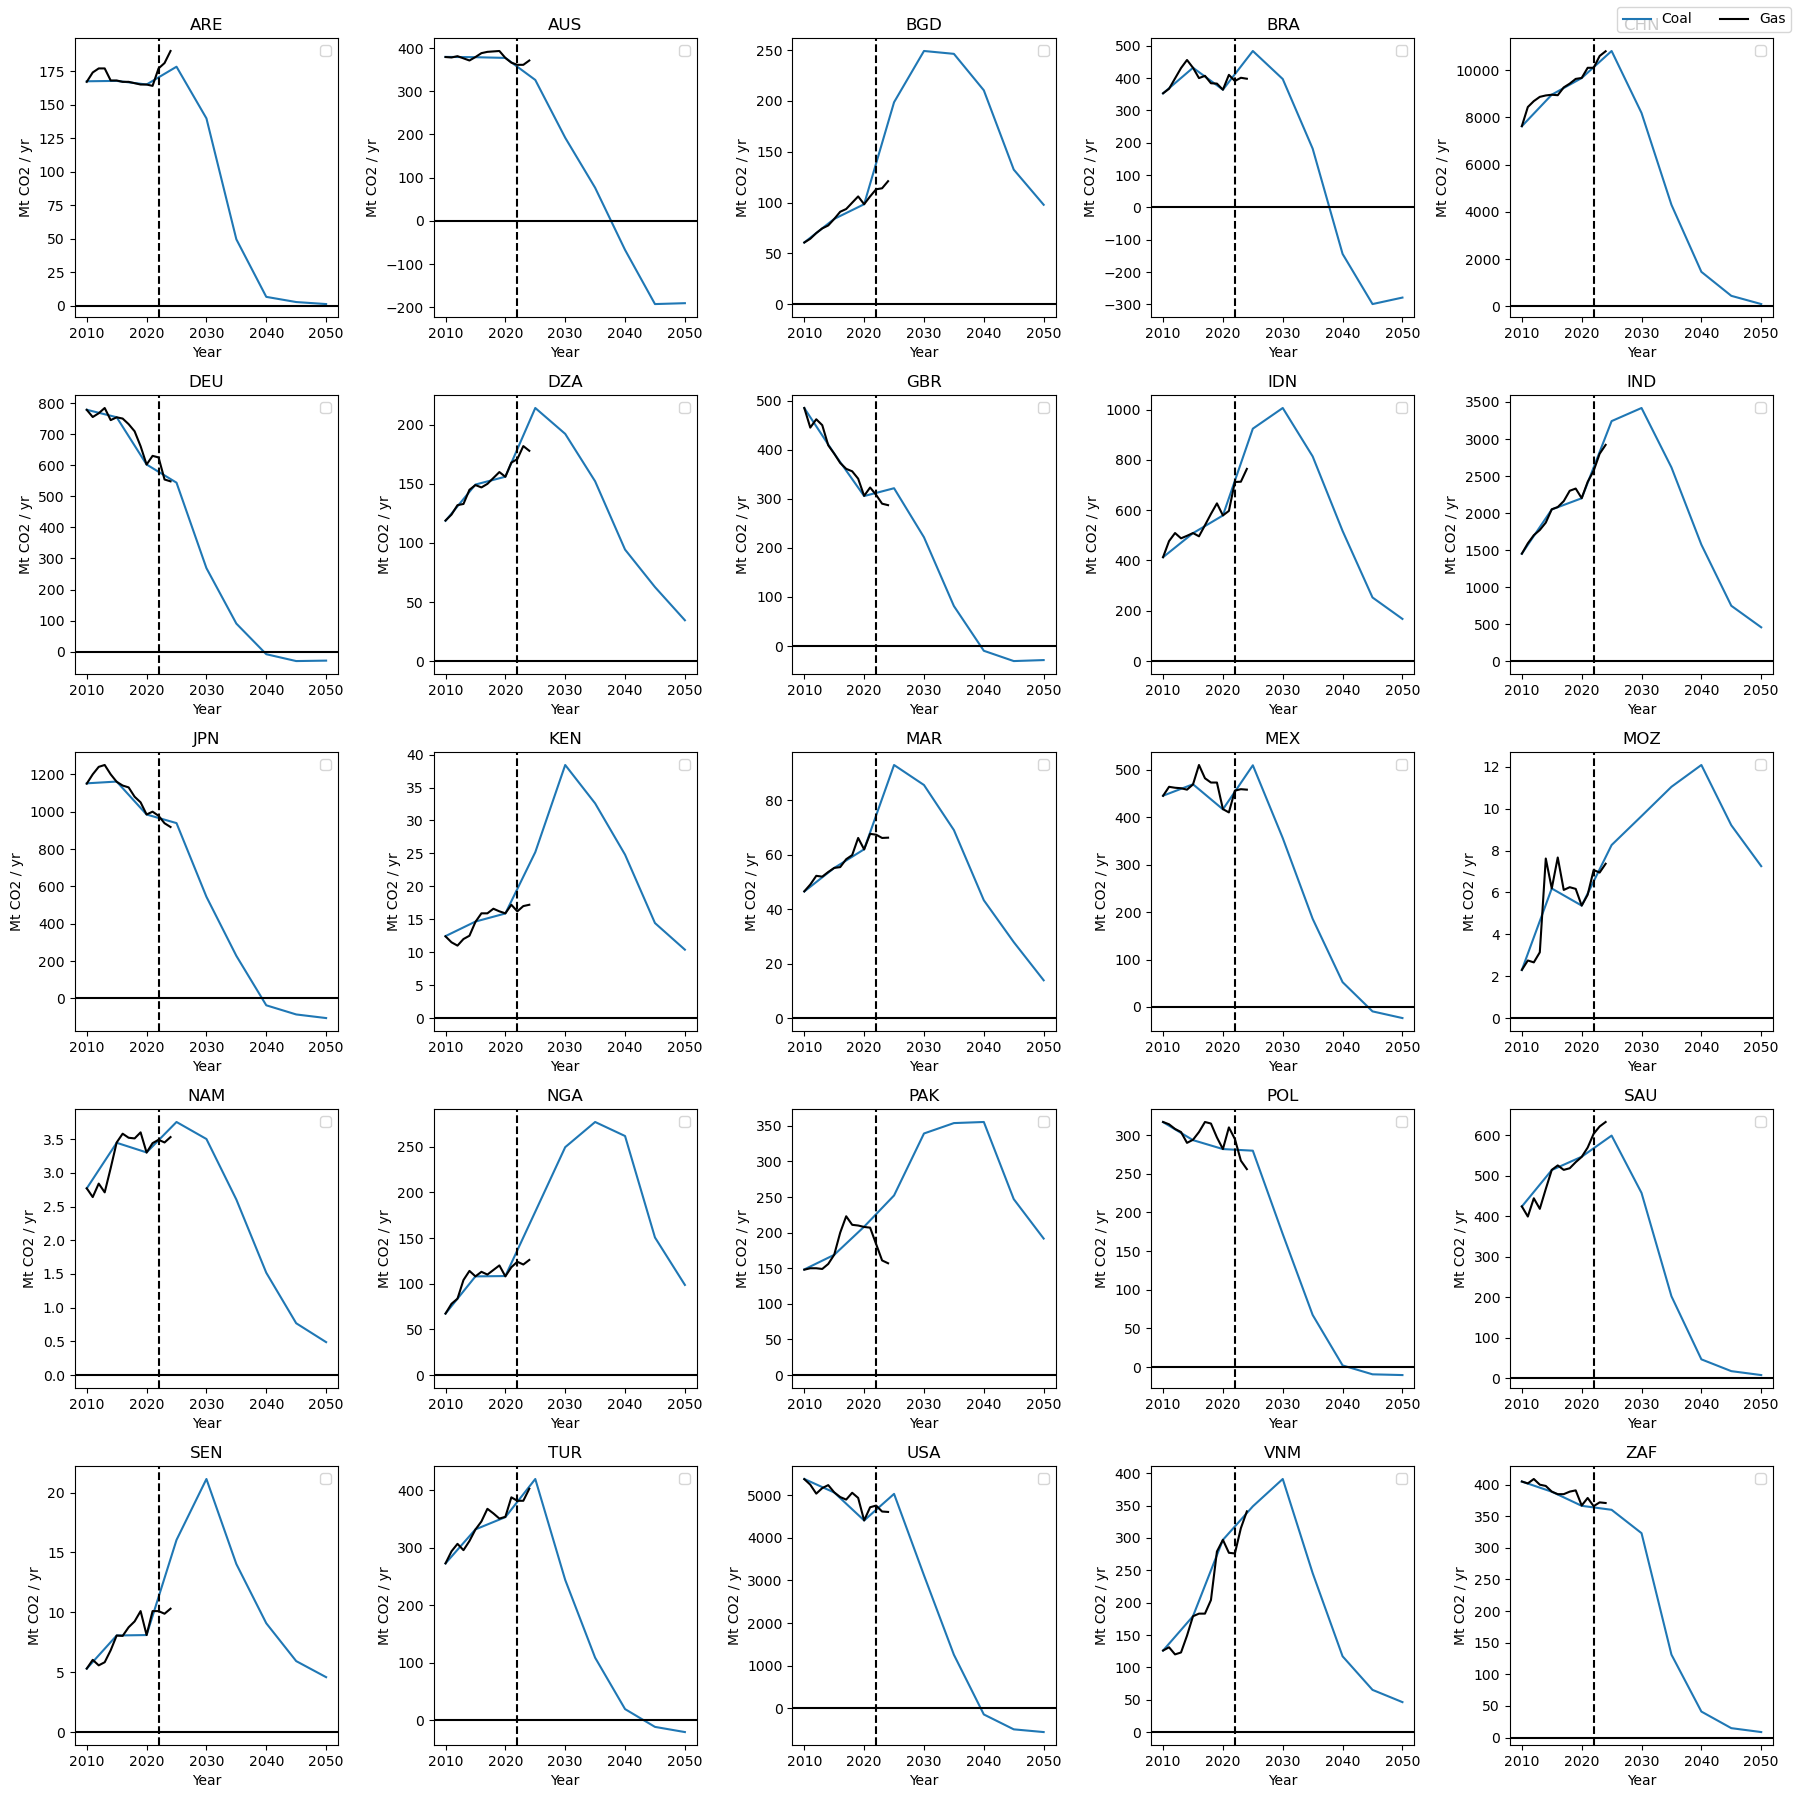

In [85]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|CO2|Energy"

for count, ax in enumerate(axes.ravel()[:]):
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    primap_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2025)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


# f.suptitle('Coal and gas power sector transition',fontsize=14,fontweight='bold', y=1)
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

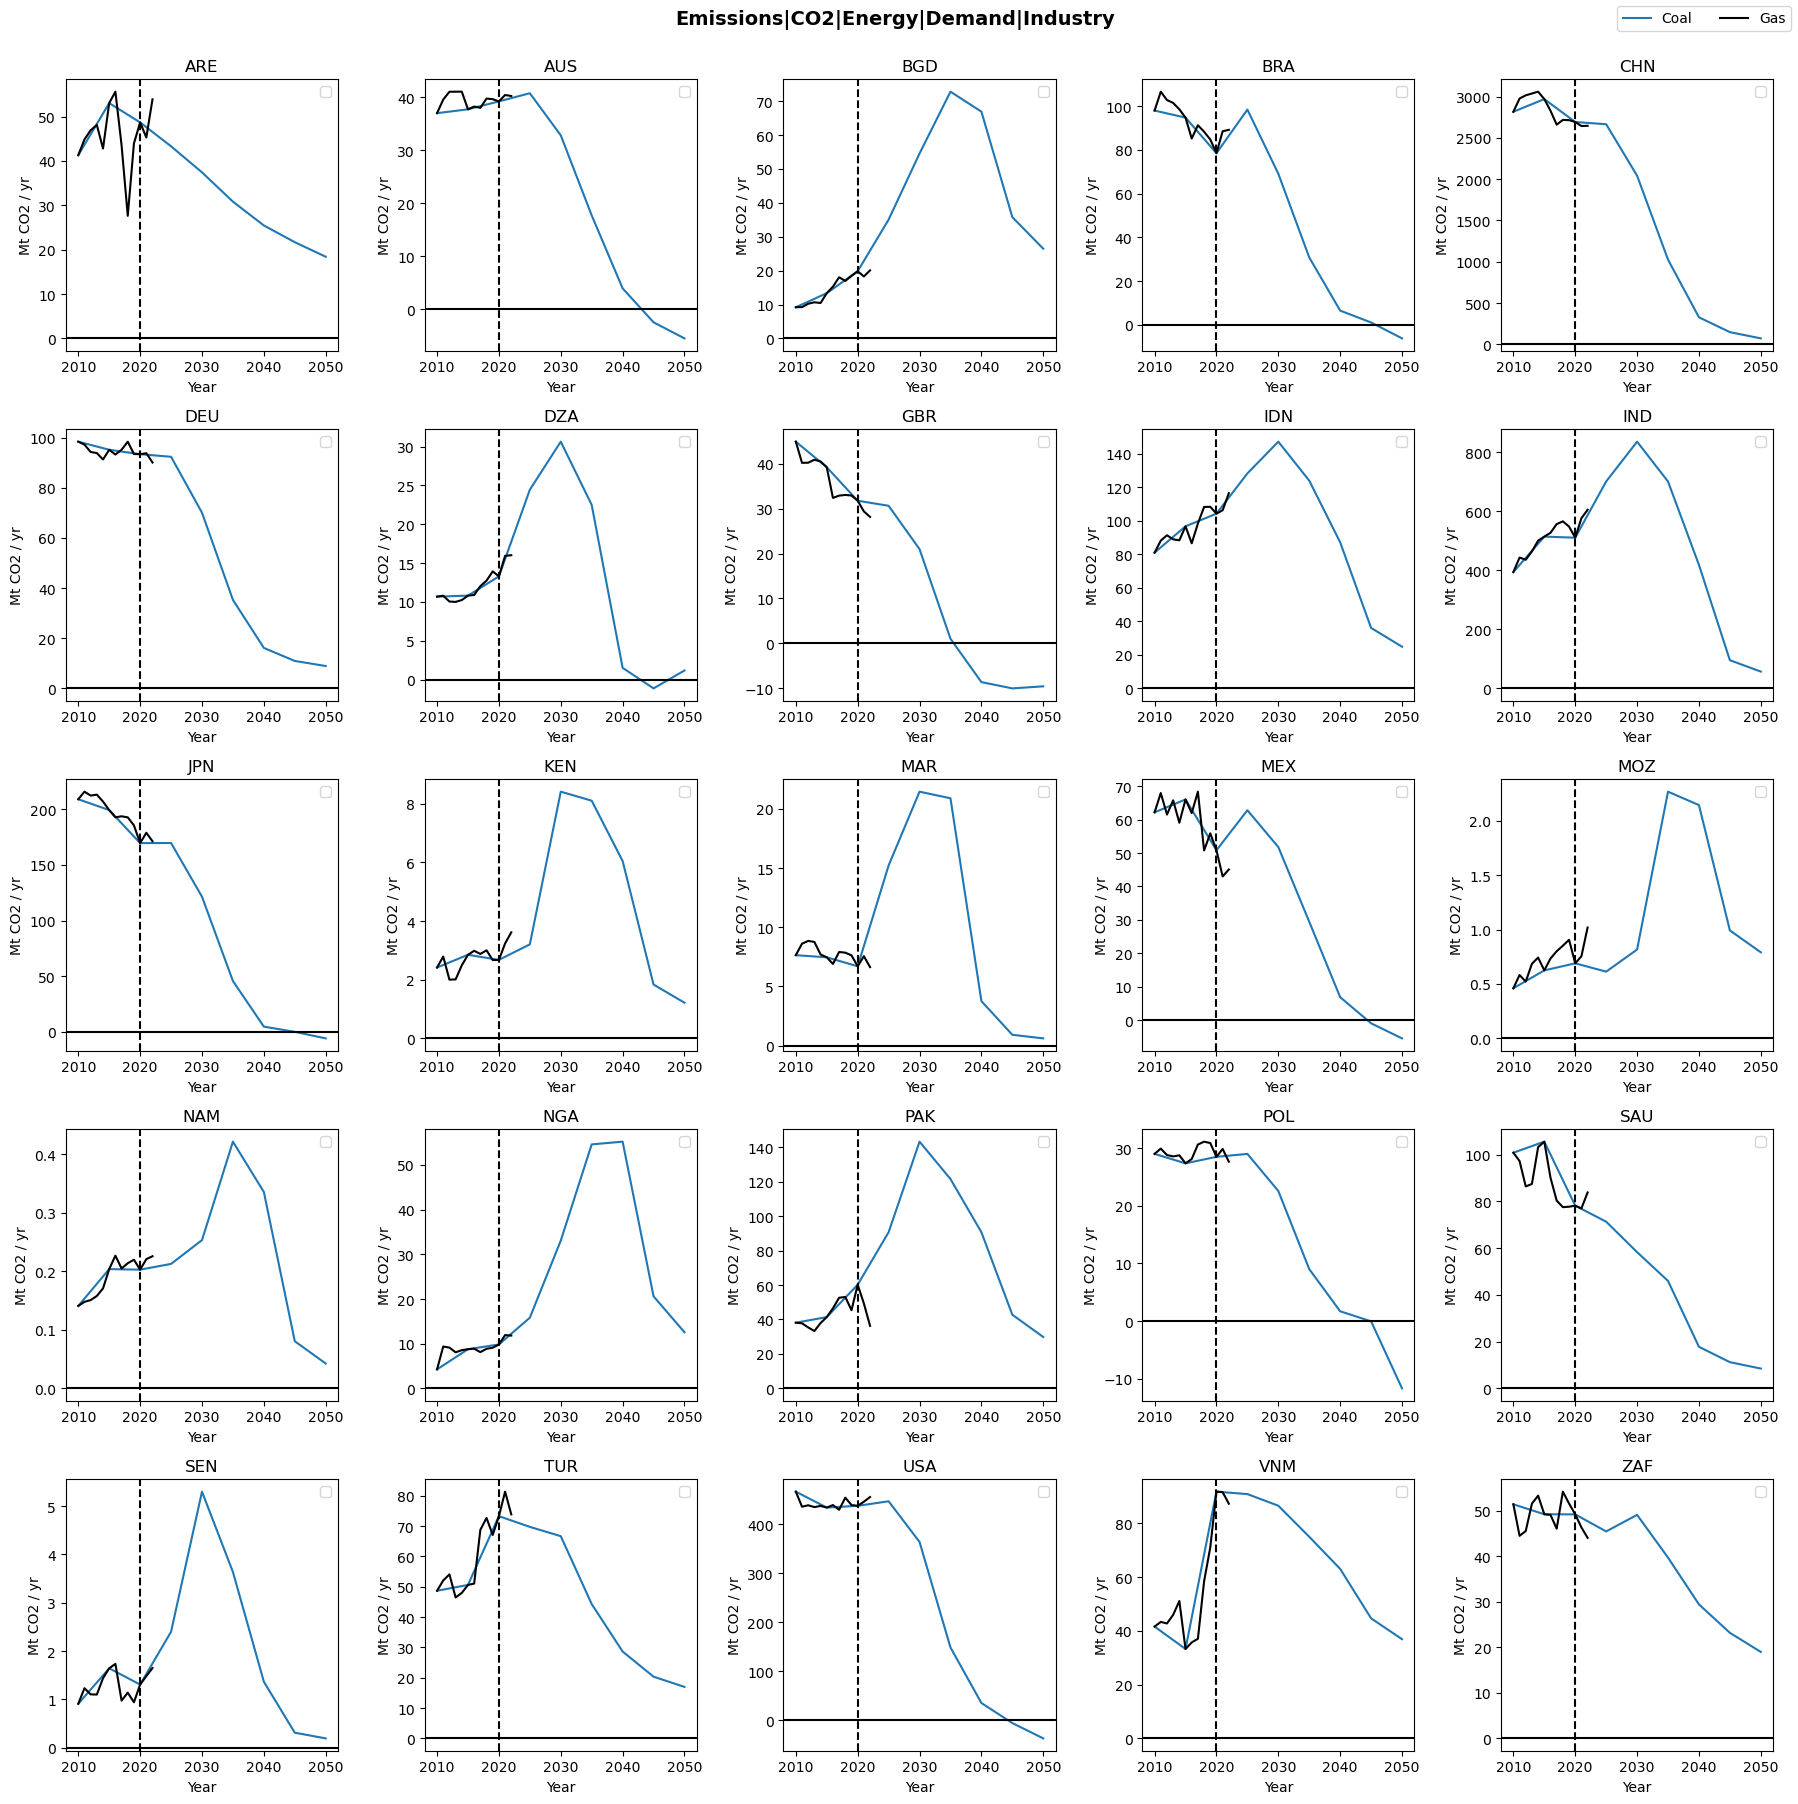

In [277]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|CO2|Energy|Demand|Industry"

for count, ax in enumerate(axes.ravel()[:]):
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    iea_co2_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2023)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2020,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!


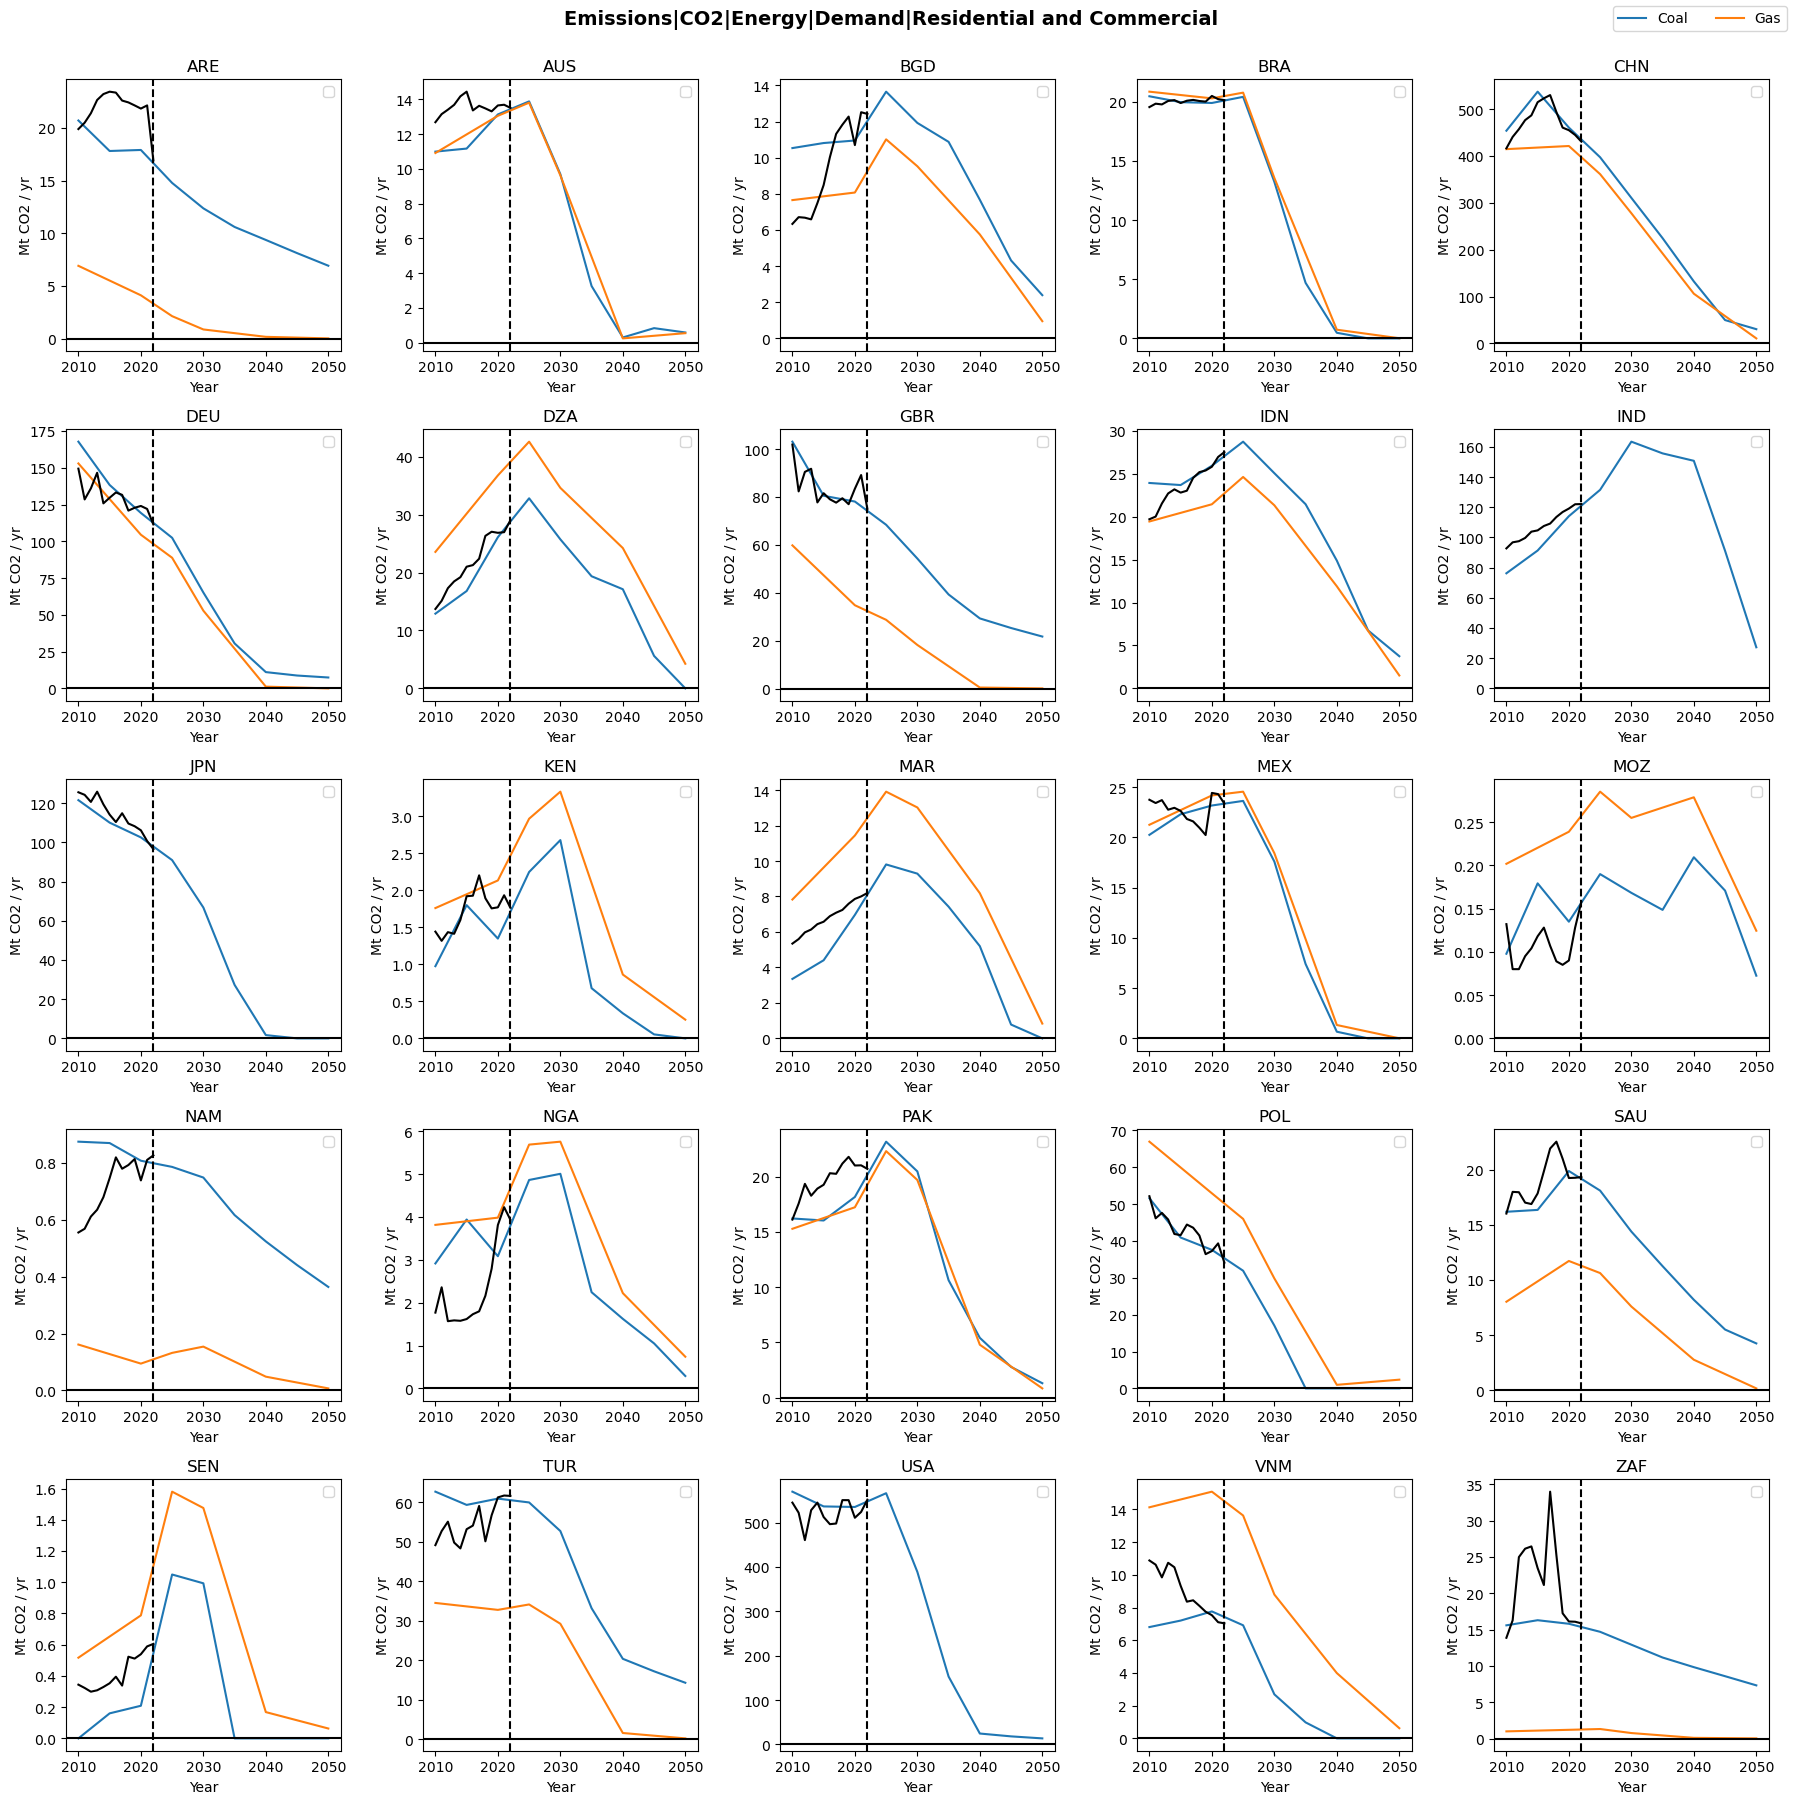

In [313]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|CO2|Energy|Demand|Residential and Commercial"

for count, ax in enumerate(axes.ravel()[:]):
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    dscale_emissions_before_harmo.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    iea_co2_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2023)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!


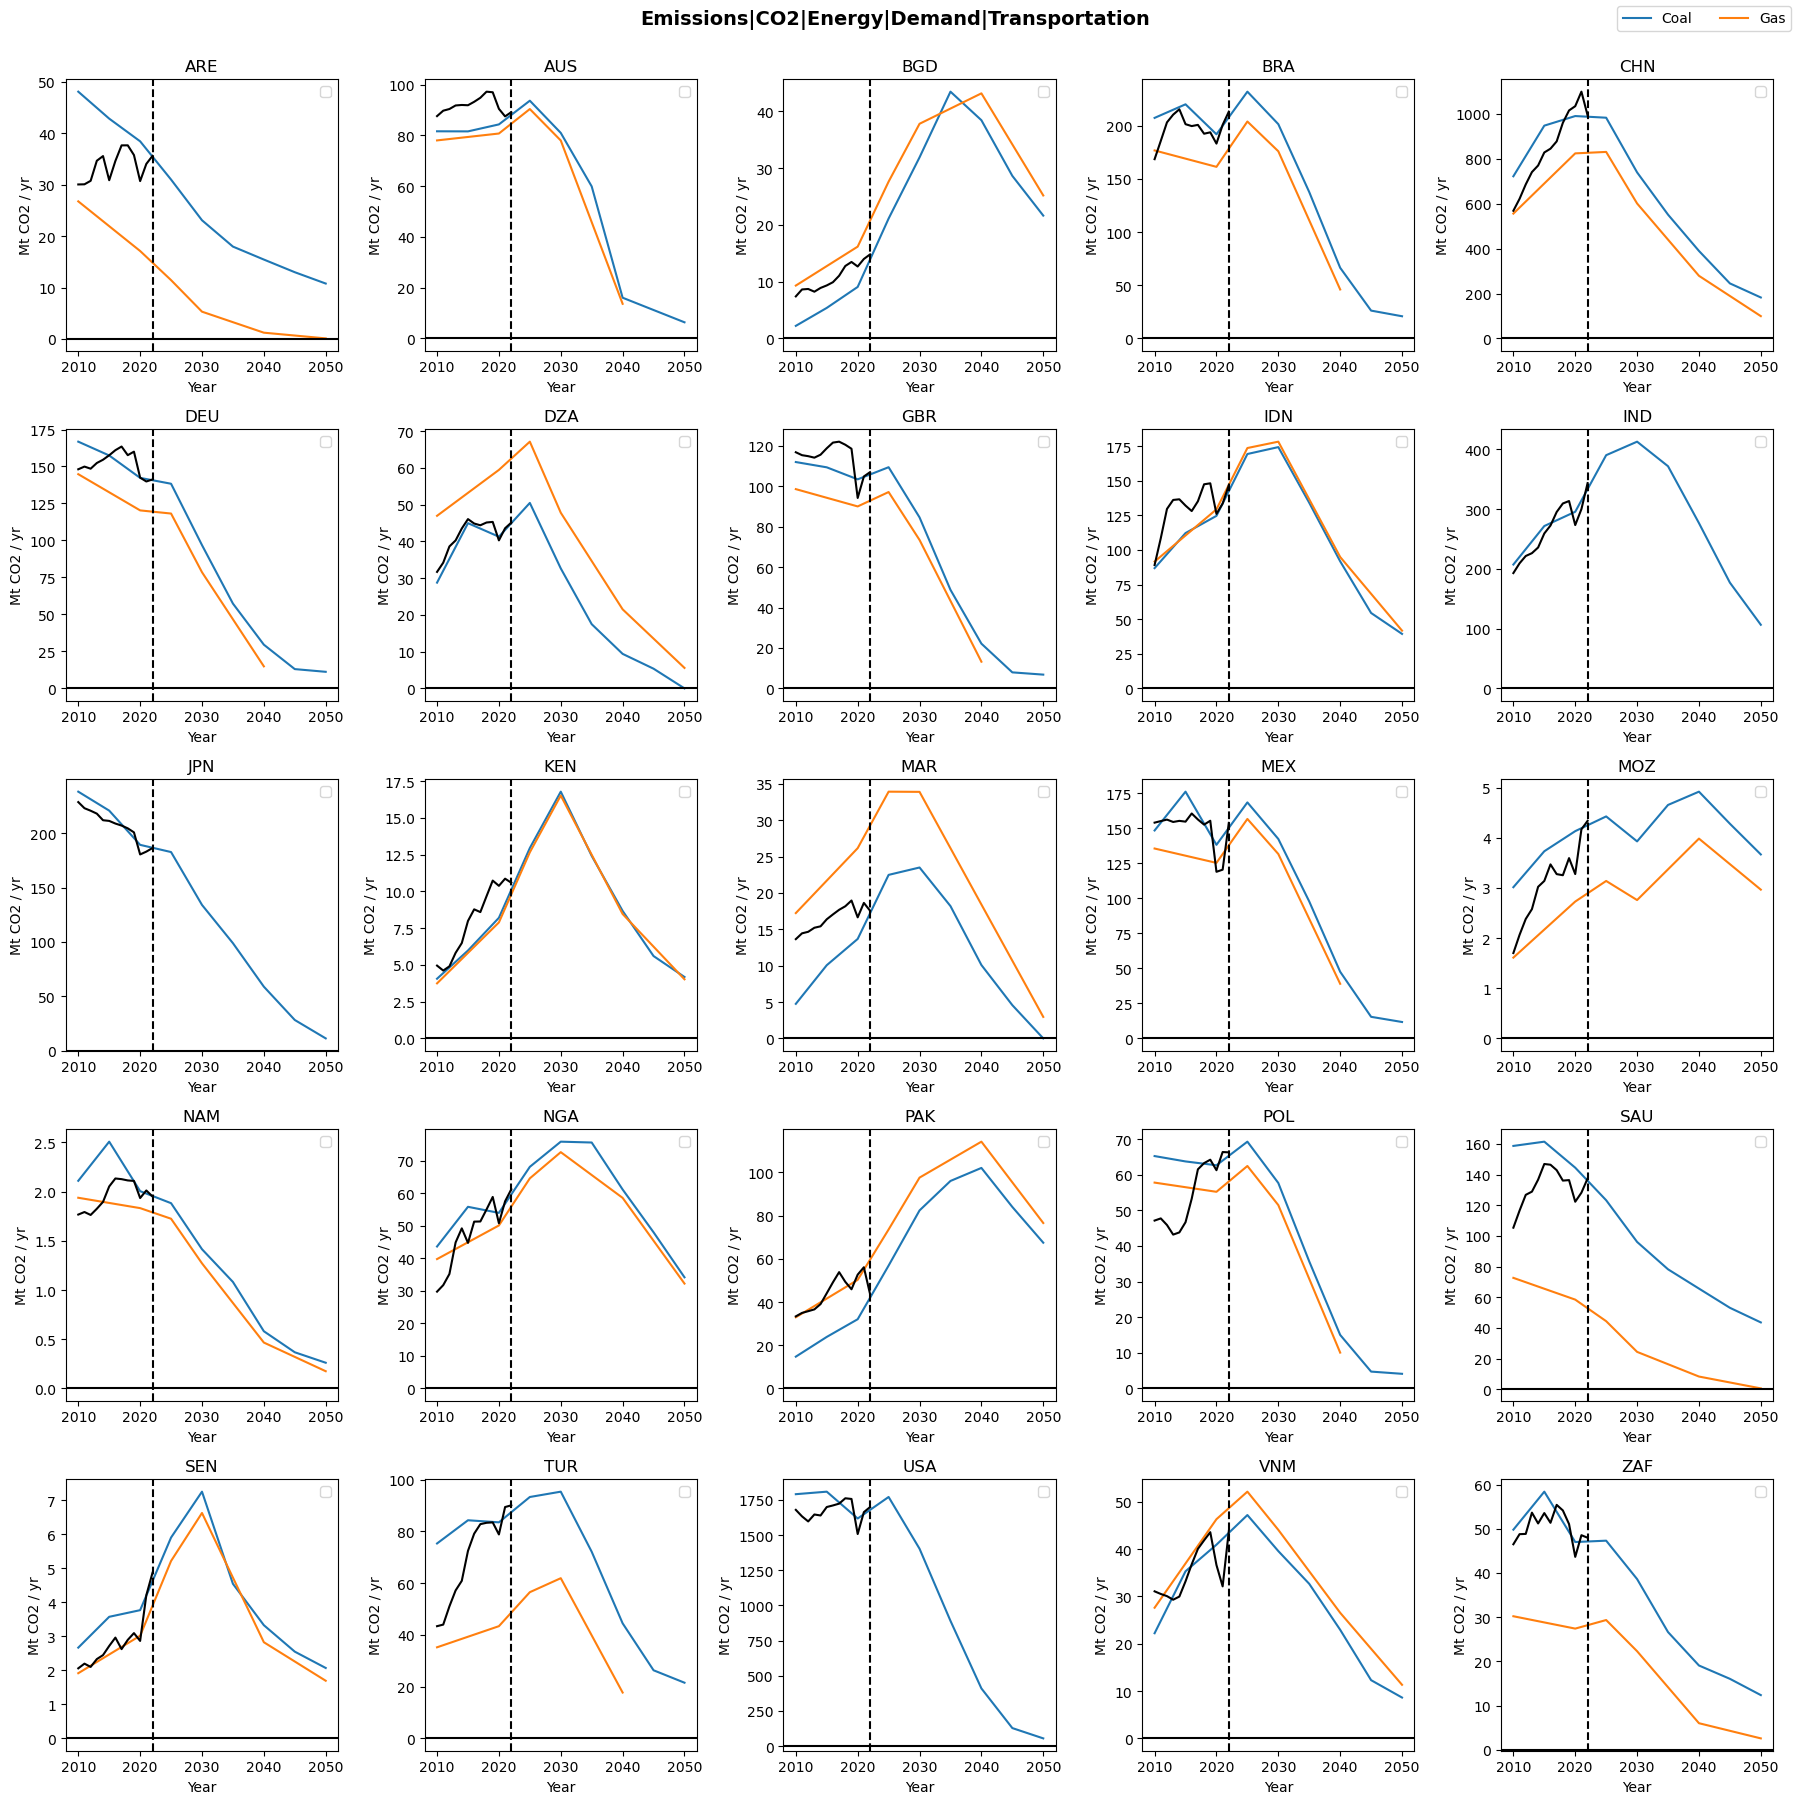

In [311]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|CO2|Energy|Demand|Transportation"

for count, ax in enumerate(axes.ravel()[:]):
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    dscale_emissions_before_harmo.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    iea_co2_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2023)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!


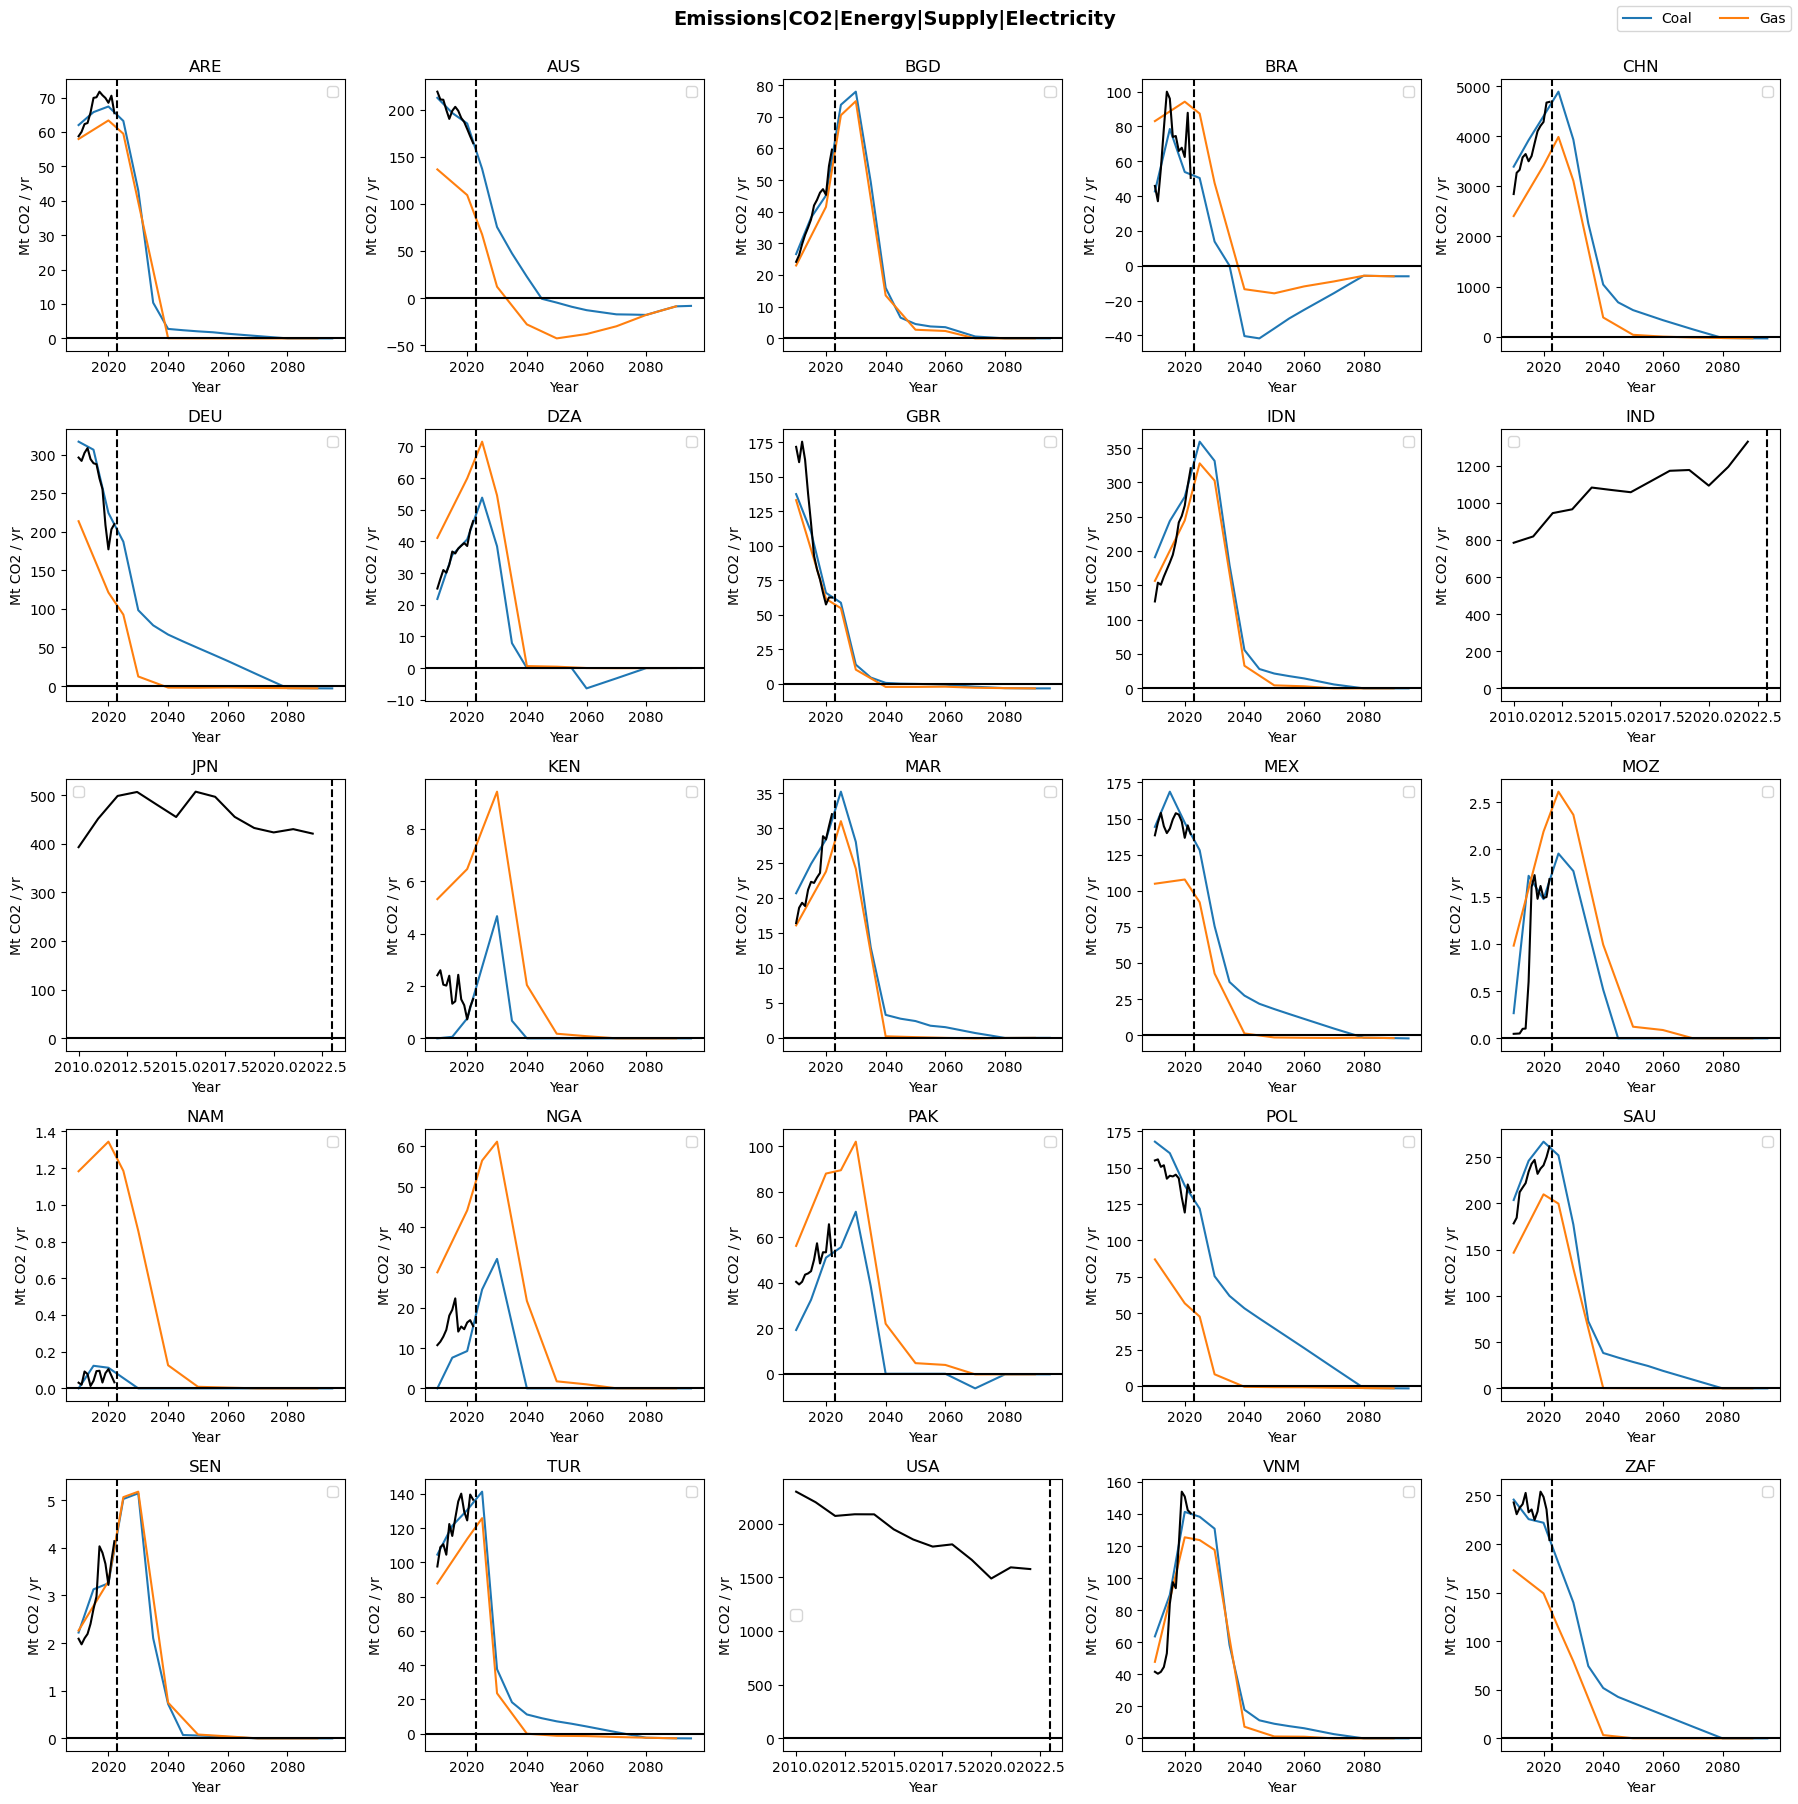

In [309]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|CO2|Energy|Supply|Electricity"

for count, ax in enumerate(axes.ravel()[:]):
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2100)).plot(ax=ax, linestyle="variable")
    dscale_emissions_before_harmo.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2100)).plot(ax=ax, linestyle="variable")
    iea_co2_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2023)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

# Consistency check

## Regional 

In [246]:
macro_df = pyam.IamDataFrame(macro_df.timeseries())

In [ ]:
input_data_harm.aggregate_region(region = "ROWO", subregions=["NEU", "CAZ"], variable = input_data_harm.variable, append=True)
macro_df.aggregate_region(region = "ROWO", subregions=["NEU", "CAZ"], variable = input_data_harm.variable, append=True)

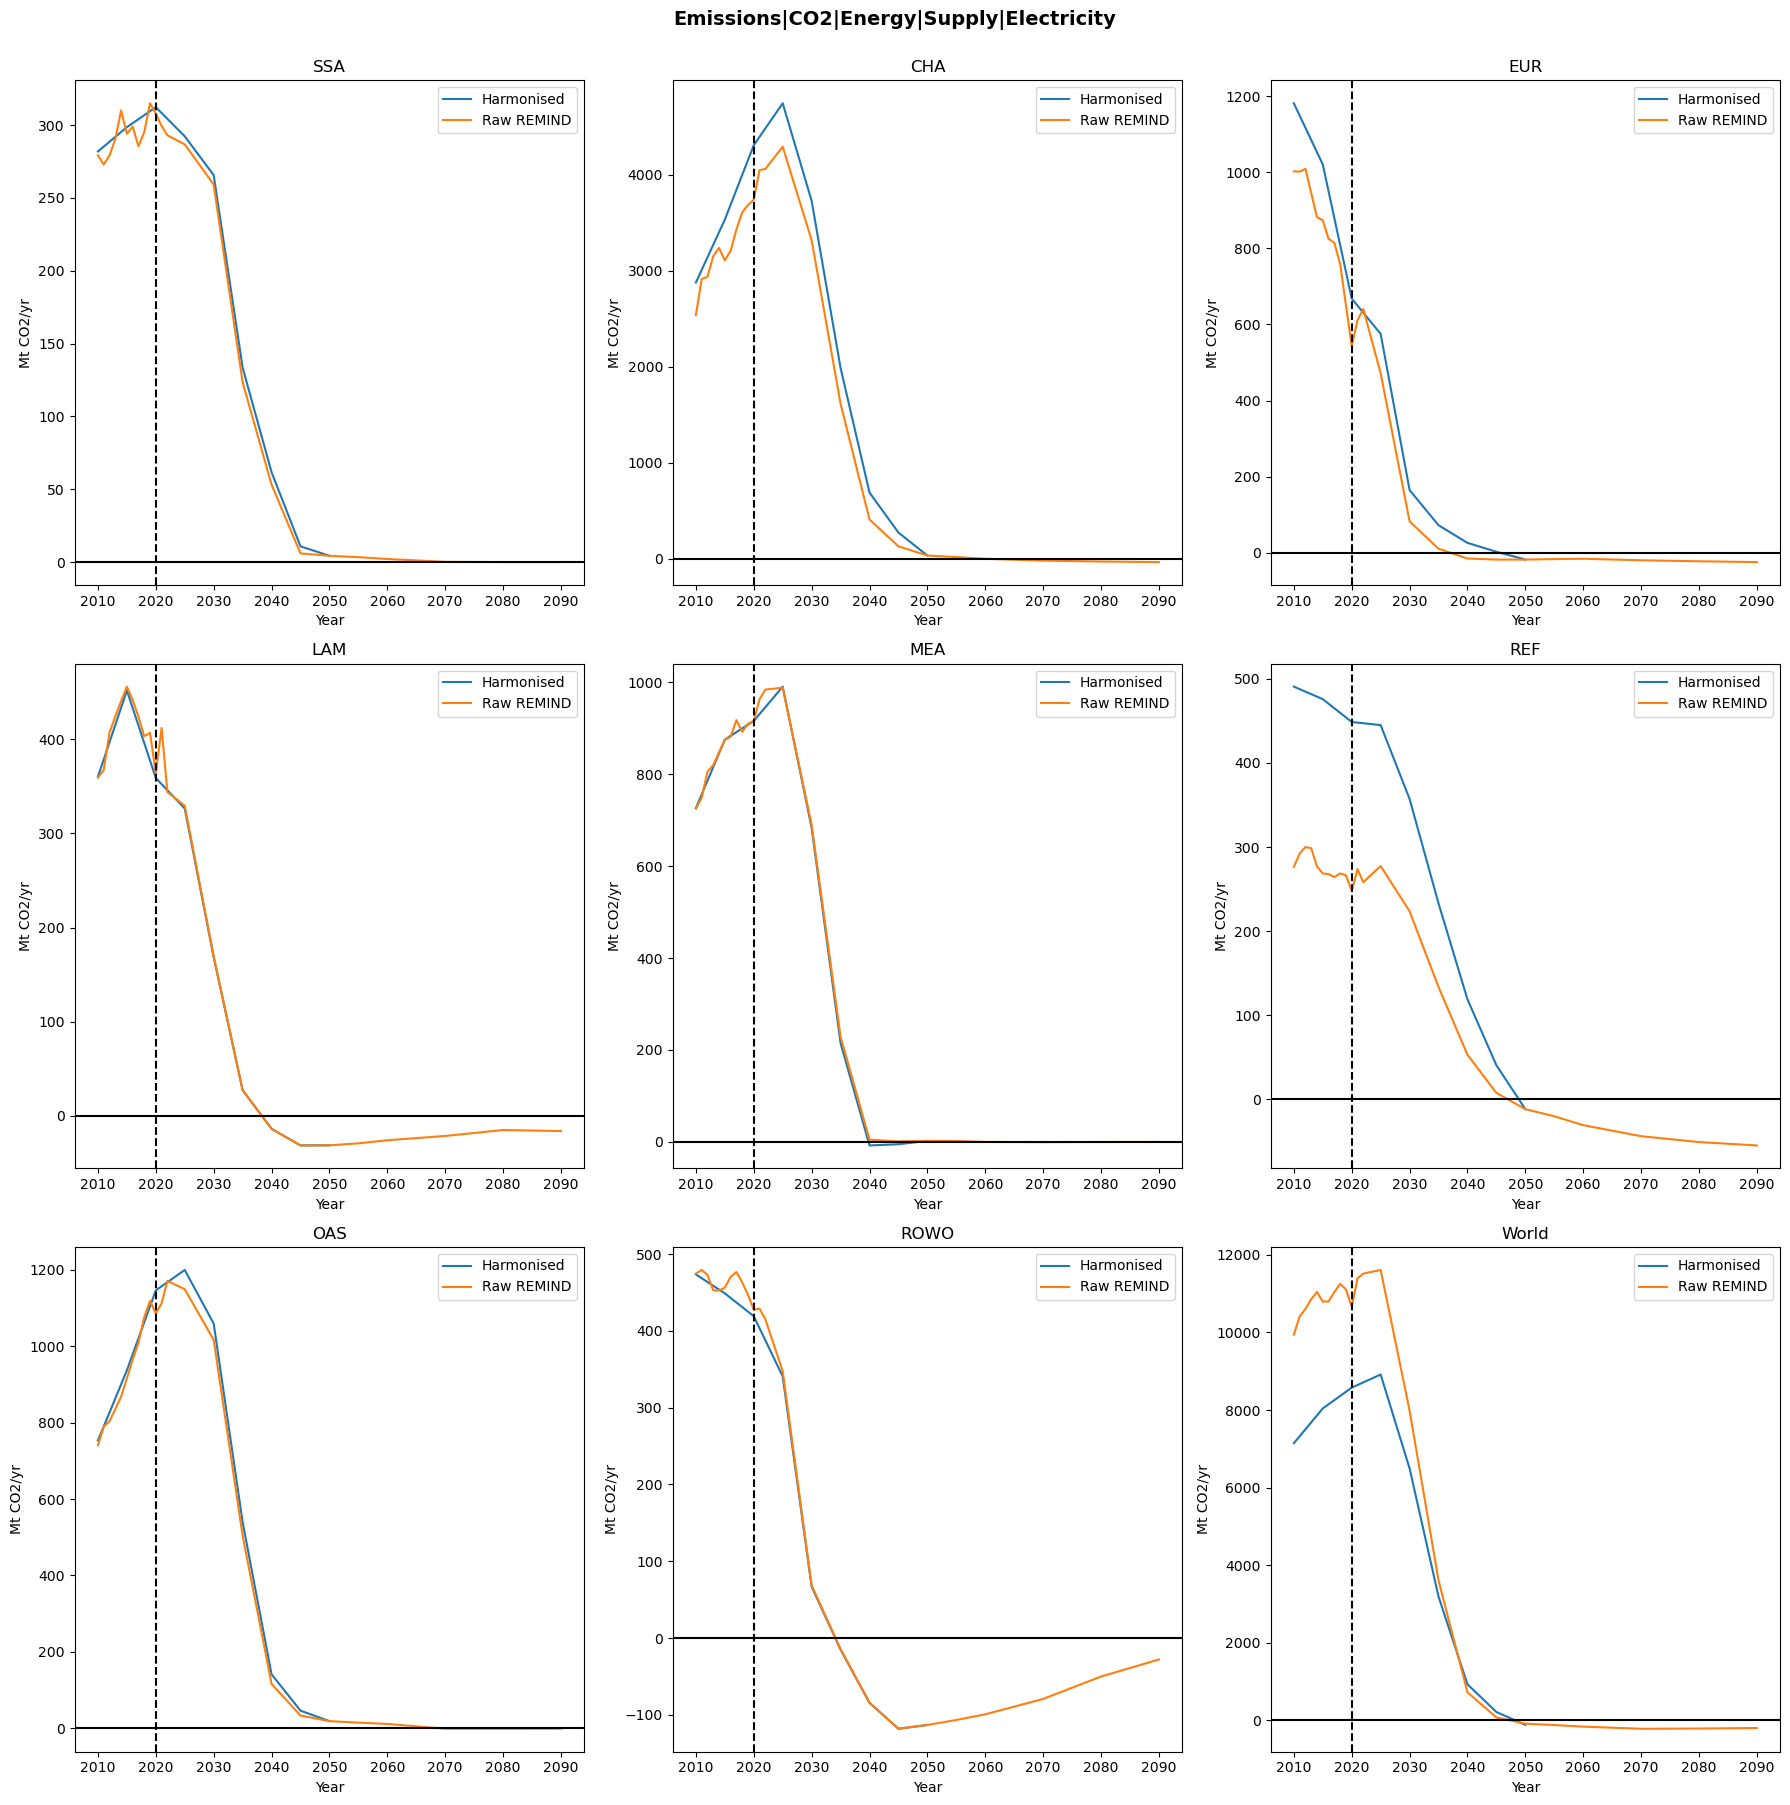

In [265]:
f, axes = plt.subplots(nrows=3,ncols=3,figsize=(18,18))
vars = "Emissions|CO2|Energy|Supply|Electricity"
regions = ['SSA', 'CHA', 'EUR', 'LAM', 'MEA', 'REF', 'OAS', 'ROWO', 'World']

for count, ax in enumerate(axes.ravel()[:]):
    plt.gca()
    macro_df.filter(scenario='NPE-core',region=regions[count],variable=vars,year=range(2010,2100)).plot(ax=ax, linestyle="variable")
    input_data_harm.filter(scenario='NPE-core',region=regions[count],variable=vars,year=range(2010,2100)).plot(ax=ax, linestyle="variable")
    # iea_co2_data.filter(region=regions[count],variable=vars,year=range(2010,2023)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2020,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(regions[count])
    ax.legend(["Harmonised", "Raw REMIND"])


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
# f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

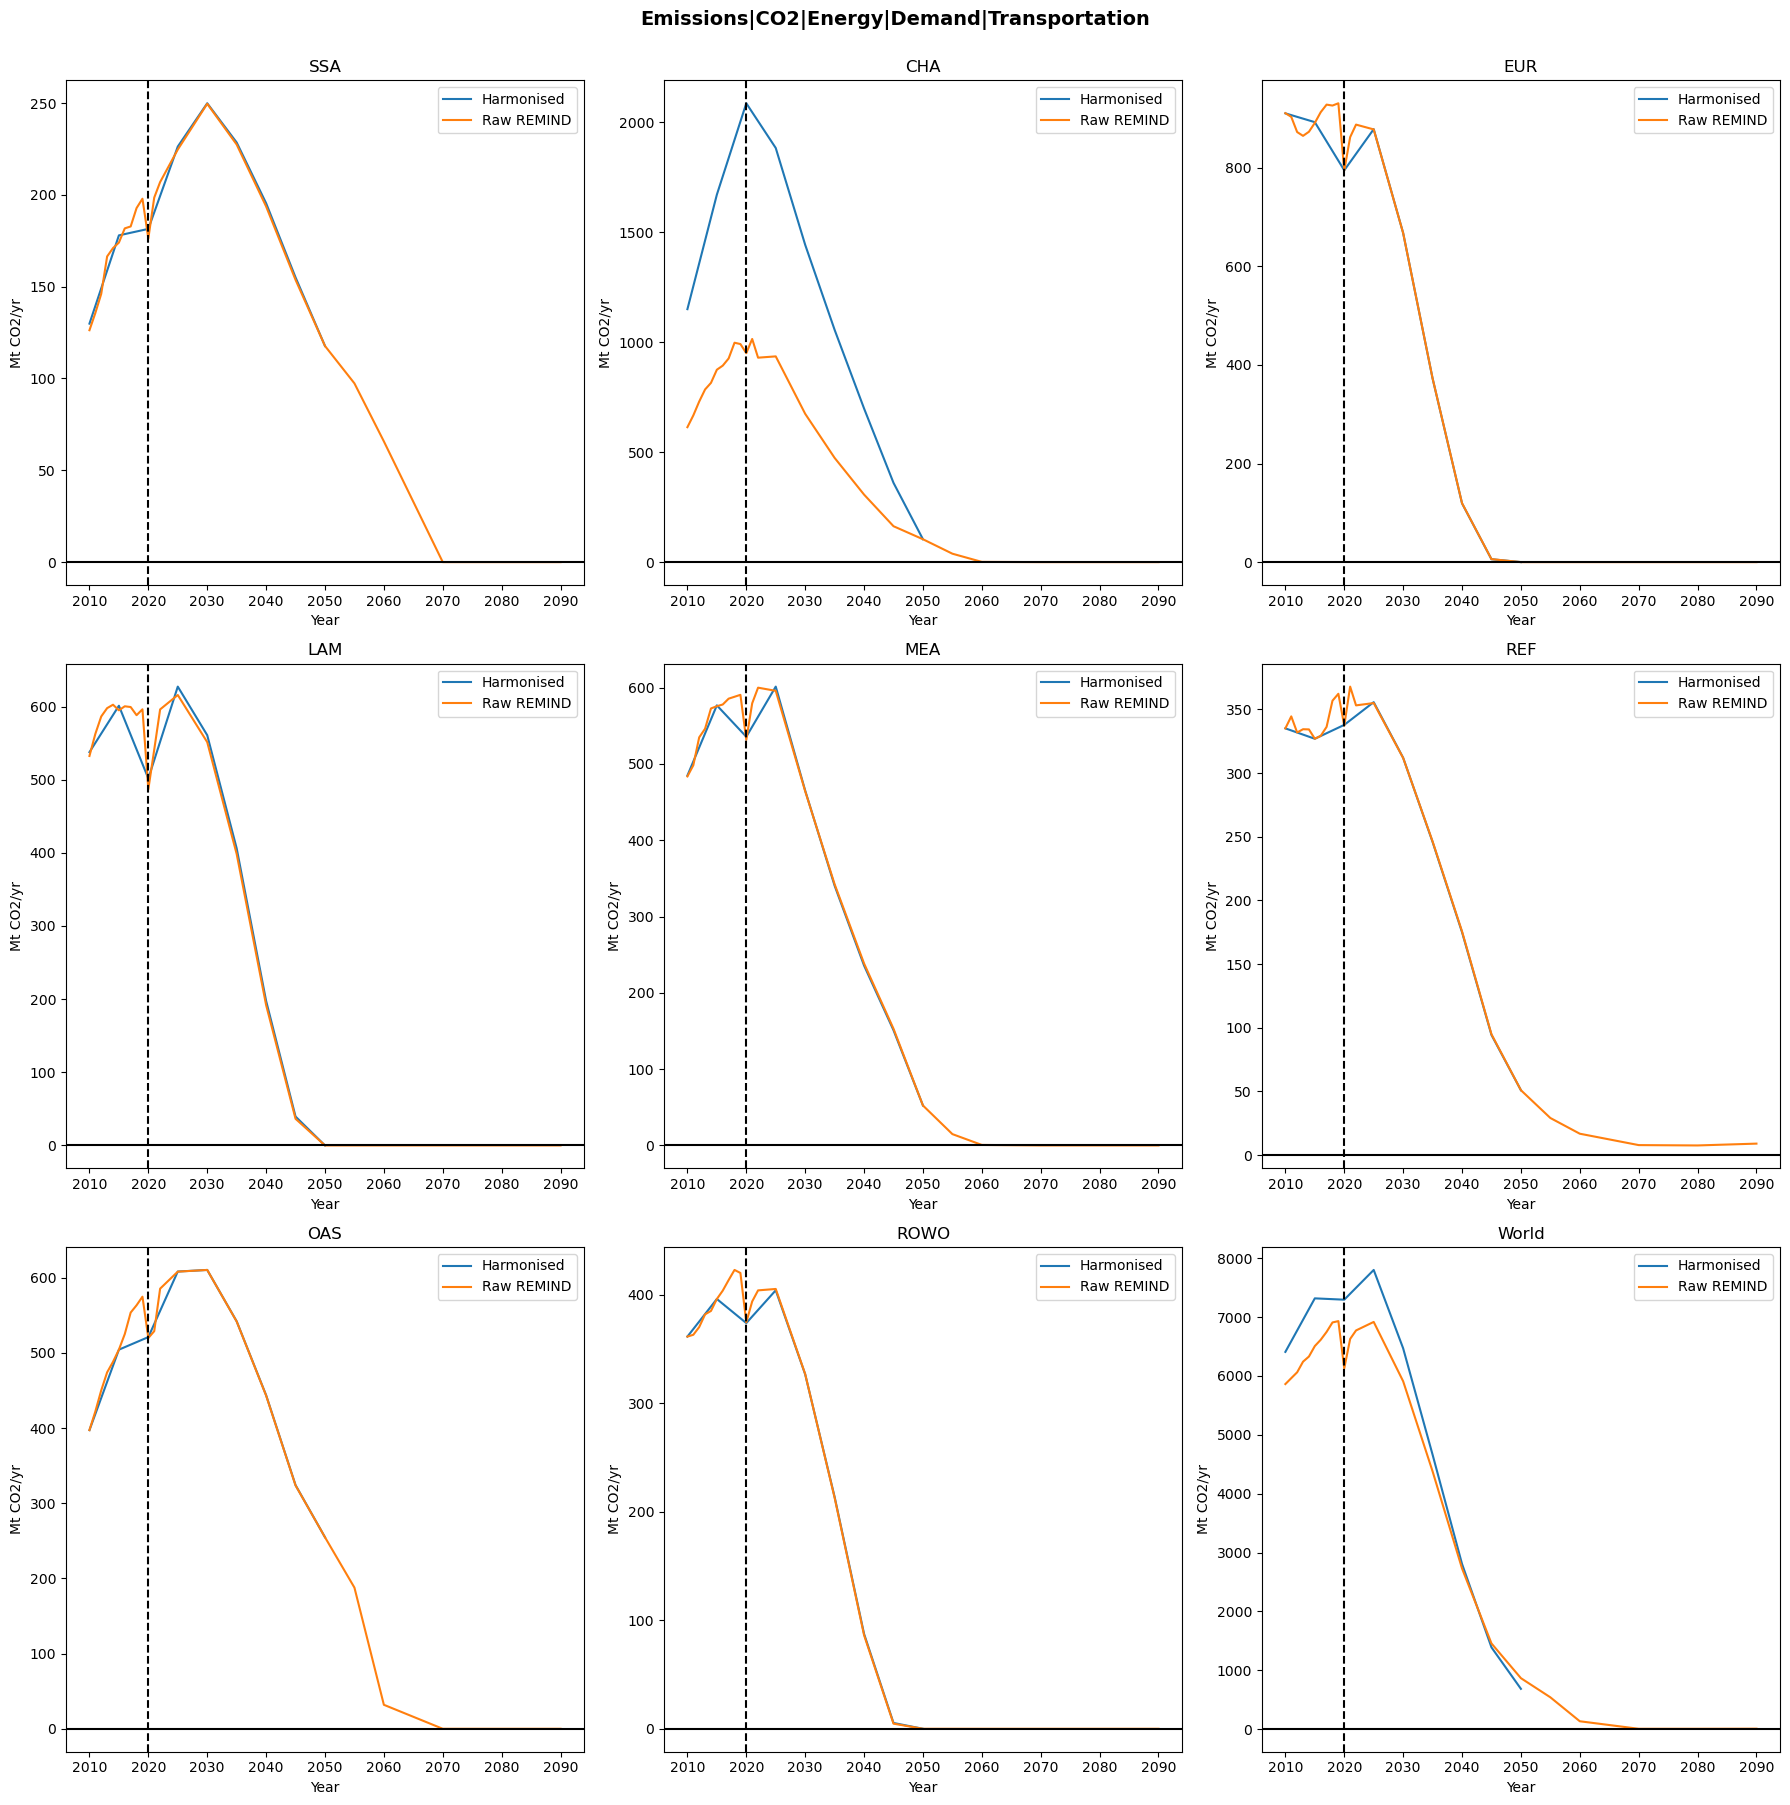

In [266]:
f, axes = plt.subplots(nrows=3,ncols=3,figsize=(18,18))
vars = "Emissions|CO2|Energy|Demand|Transportation"
regions = ['SSA', 'CHA', 'EUR', 'LAM', 'MEA', 'REF', 'OAS', 'ROWO', 'World']

for count, ax in enumerate(axes.ravel()[:]):
    plt.gca()
    macro_df.filter(scenario='NPE-core',region=regions[count],variable=vars,year=range(2010,2100)).plot(ax=ax, linestyle="variable")
    input_data_harm.filter(scenario='NPE-core',region=regions[count],variable=vars,year=range(2010,2100)).plot(ax=ax, linestyle="variable")
    # iea_co2_data.filter(region=regions[count],variable=vars,year=range(2010,2023)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2020,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(regions[count])
    ax.legend(["Harmonised", "Raw REMIND"])


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
# f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

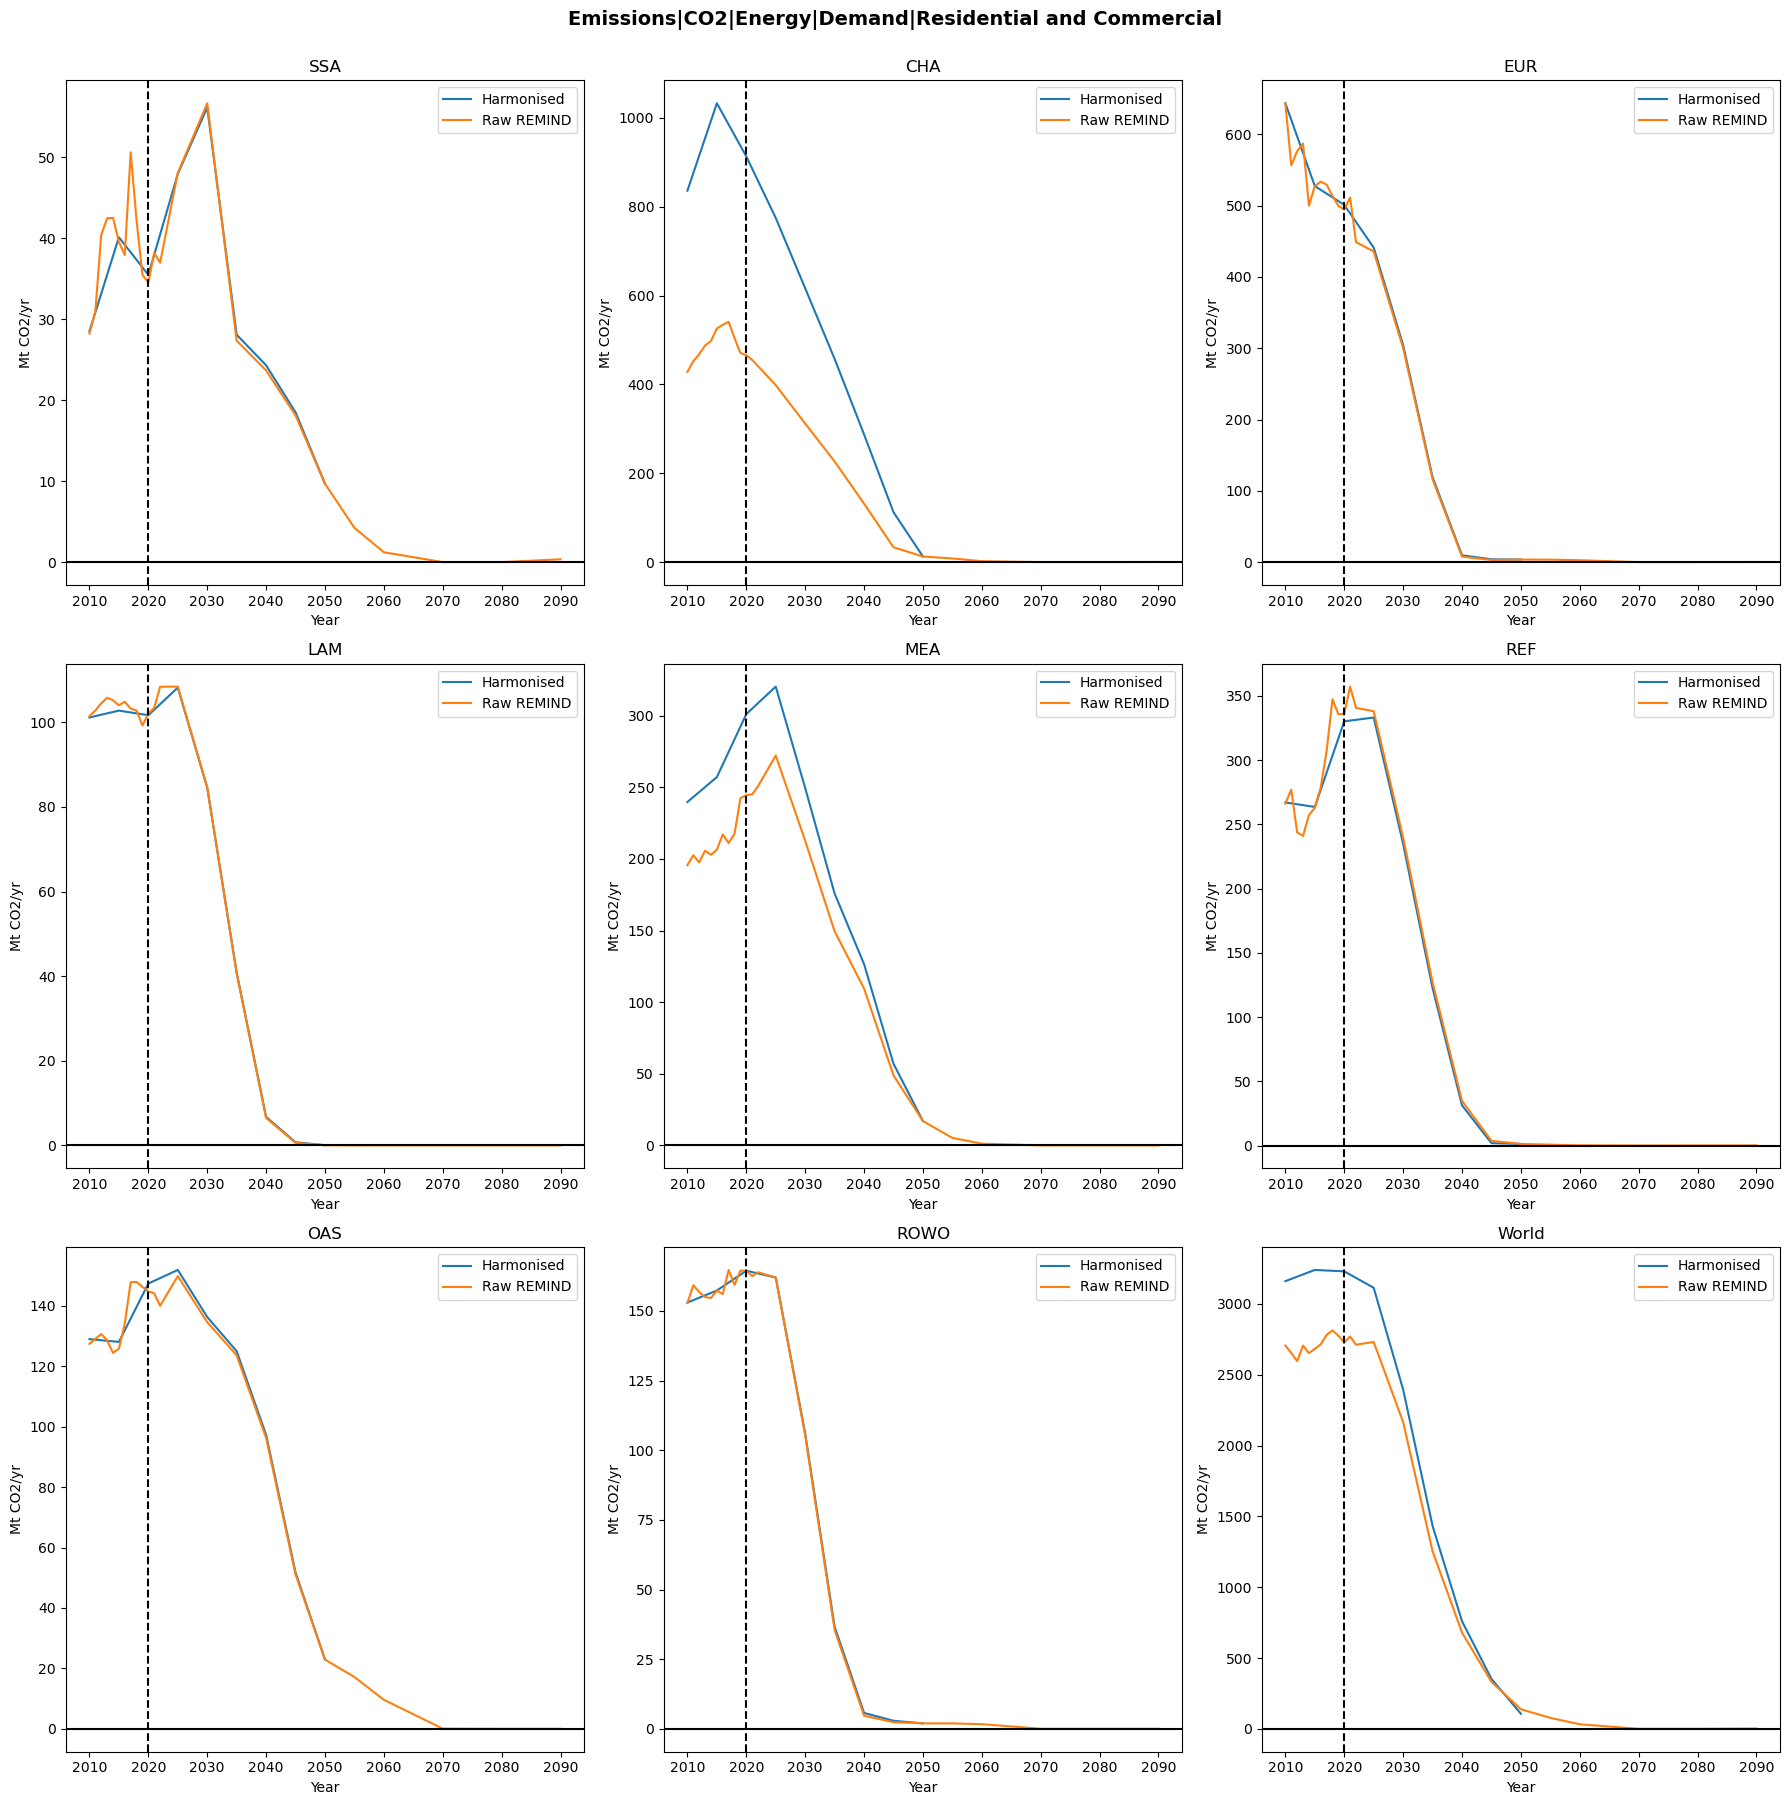

In [268]:
f, axes = plt.subplots(nrows=3,ncols=3,figsize=(18,18))
vars = "Emissions|CO2|Energy|Demand|Residential and Commercial"
regions = ['SSA', 'CHA', 'EUR', 'LAM', 'MEA', 'REF', 'OAS', 'ROWO', 'World']

for count, ax in enumerate(axes.ravel()[:]):
    plt.gca()
    macro_df.filter(scenario='NPE-core',region=regions[count],variable=vars,year=range(2010,2100)).plot(ax=ax, linestyle="variable")
    input_data_harm.filter(scenario='NPE-core',region=regions[count],variable=vars,year=range(2010,2100)).plot(ax=ax, linestyle="variable")
    # iea_co2_data.filter(region=regions[count],variable=vars,year=range(2010,2023)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2020,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(regions[count])
    ax.legend(["Harmonised", "Raw REMIND"])


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
# f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

## Sectoral

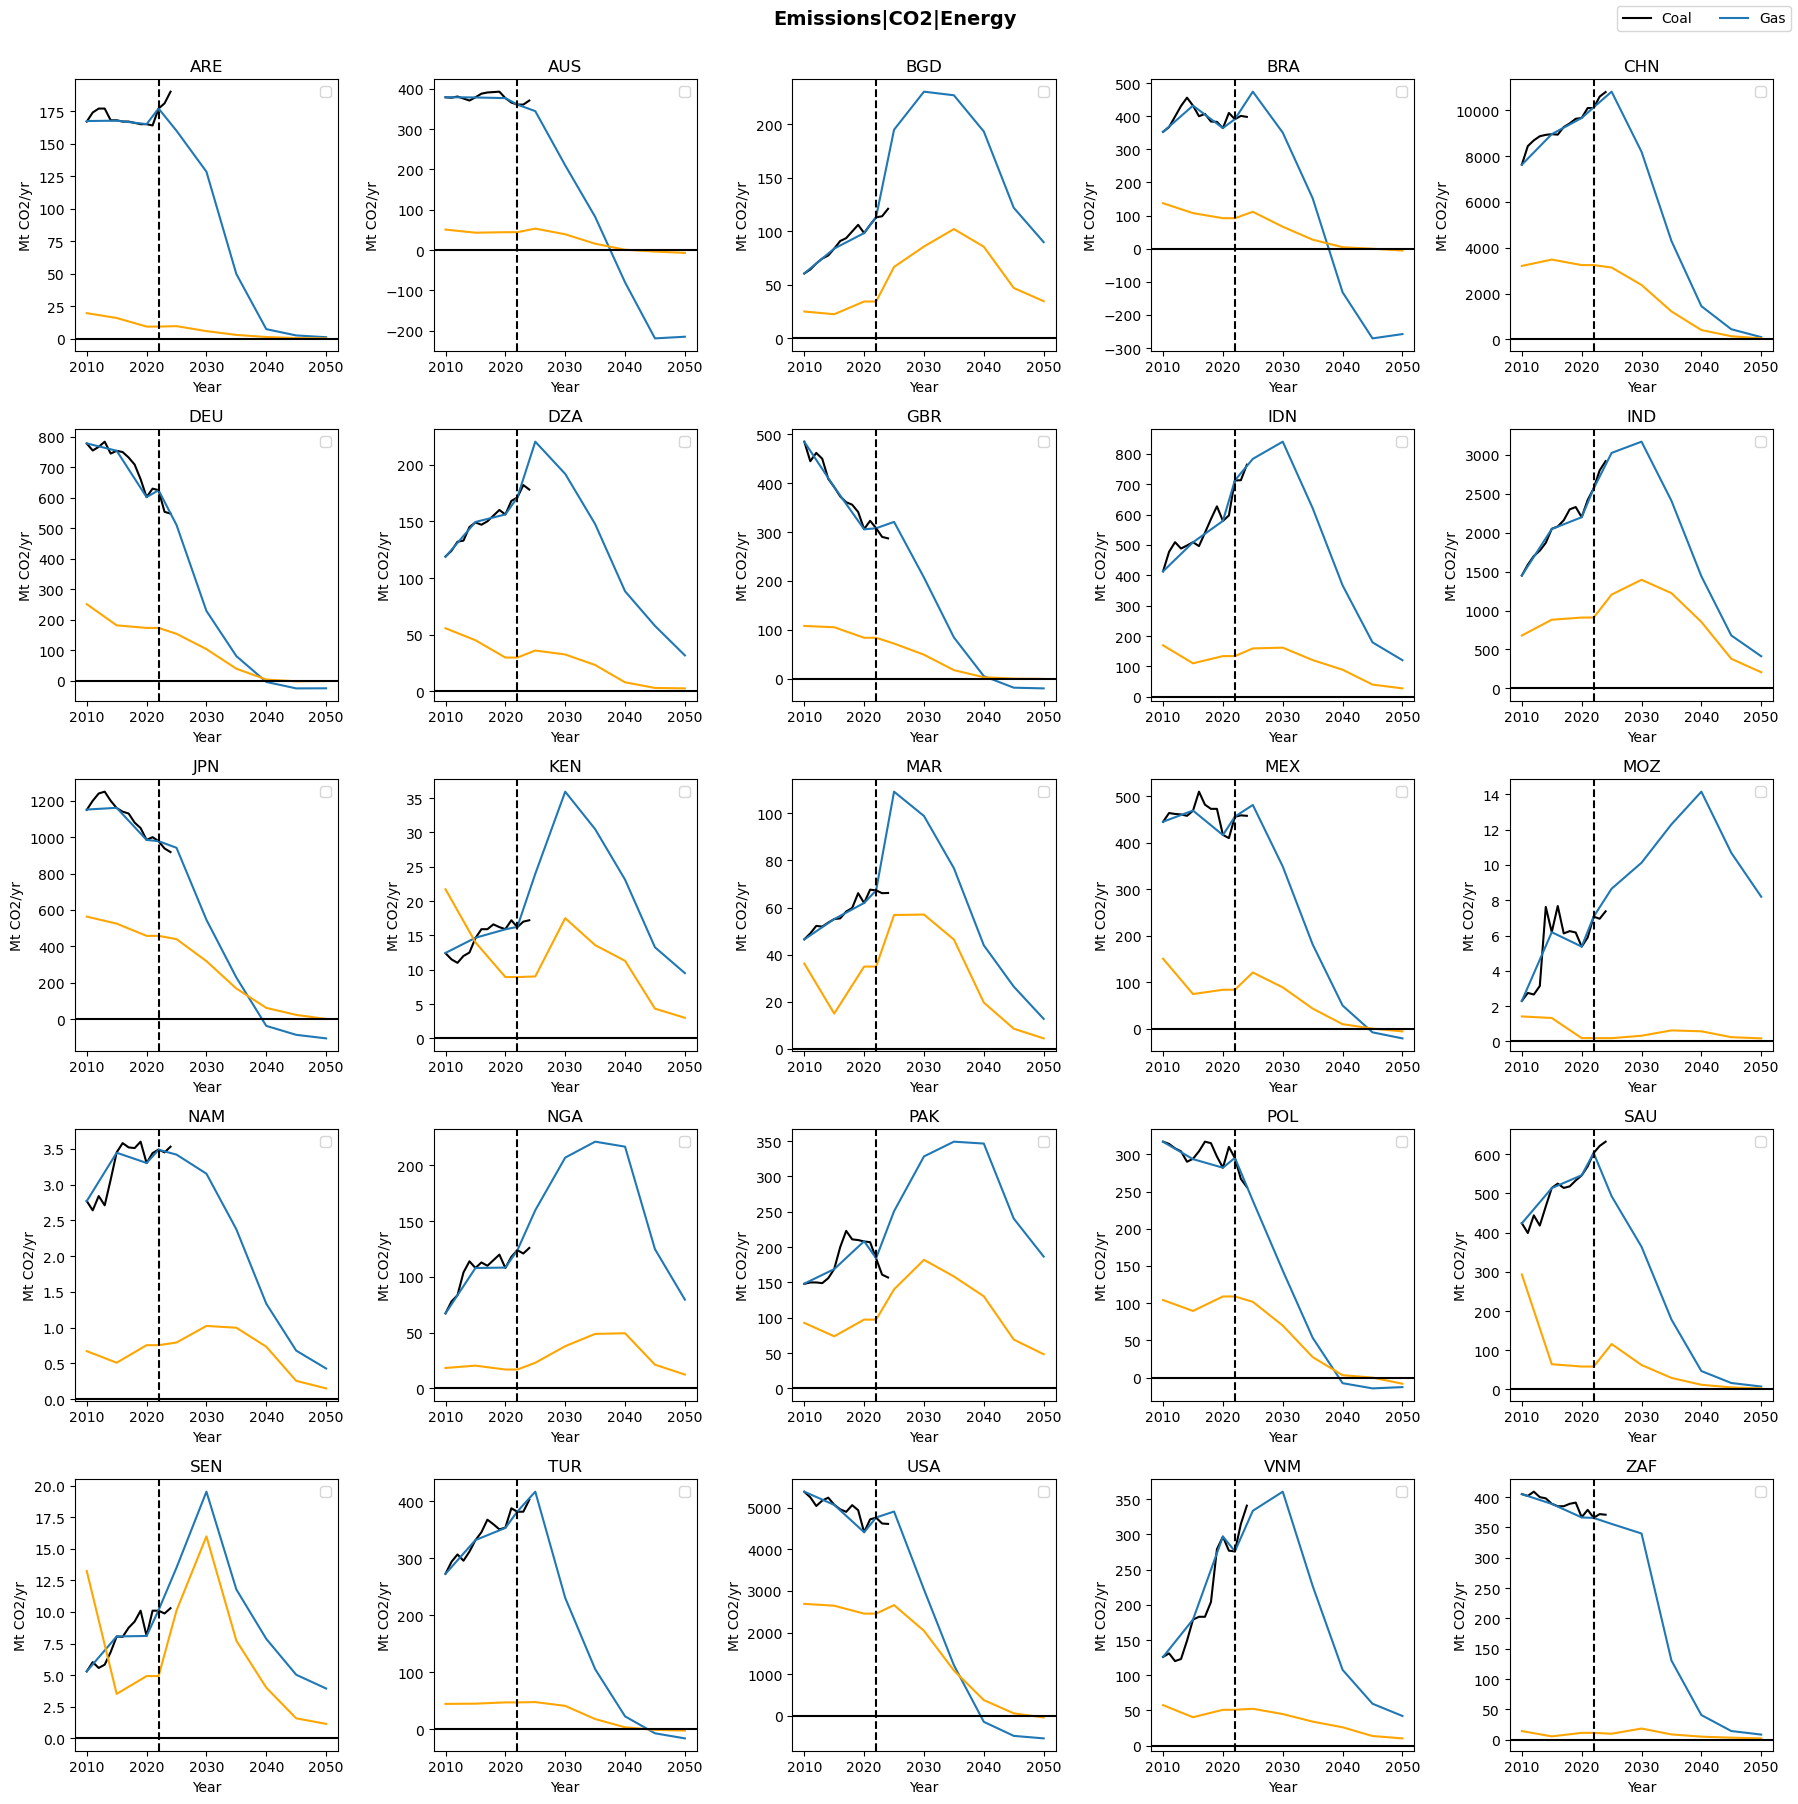

In [79]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|CO2|Energy"

for count, ax in enumerate(axes.ravel()[:]):
    primap_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2025)).plot(ax=ax,color='k', linestyle = "variable")
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable")
    dscale_emissions.aggregate('Emissions|CO2|Energy|Agg', ['Emissions|CO2|Energy|Demand|Industry',
 'Emissions|CO2|Energy|Demand|Residential and Commercial',
 'Emissions|CO2|Energy|Supply|Electricity|Oil',
 'Emissions|CO2|Energy|Demand|Transportation']).filter(region = IKEA_ISOS[count],year=range(2010,2051)).plot(ax=ax,color='orange', linestyle = "variable")
    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle(vars,fontsize=14,fontweight='bold', y=1)
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

# Comparing with MDPs

In [38]:
mdps_remind=mdps_remind.rename(variable = {
    "2ºC": "Emissions|Kyoto Gases (incl. indirect AFOLU)", 
    "1.5ºC": "Emissions|Kyoto Gases (incl. indirect AFOLU)"
})

pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is 

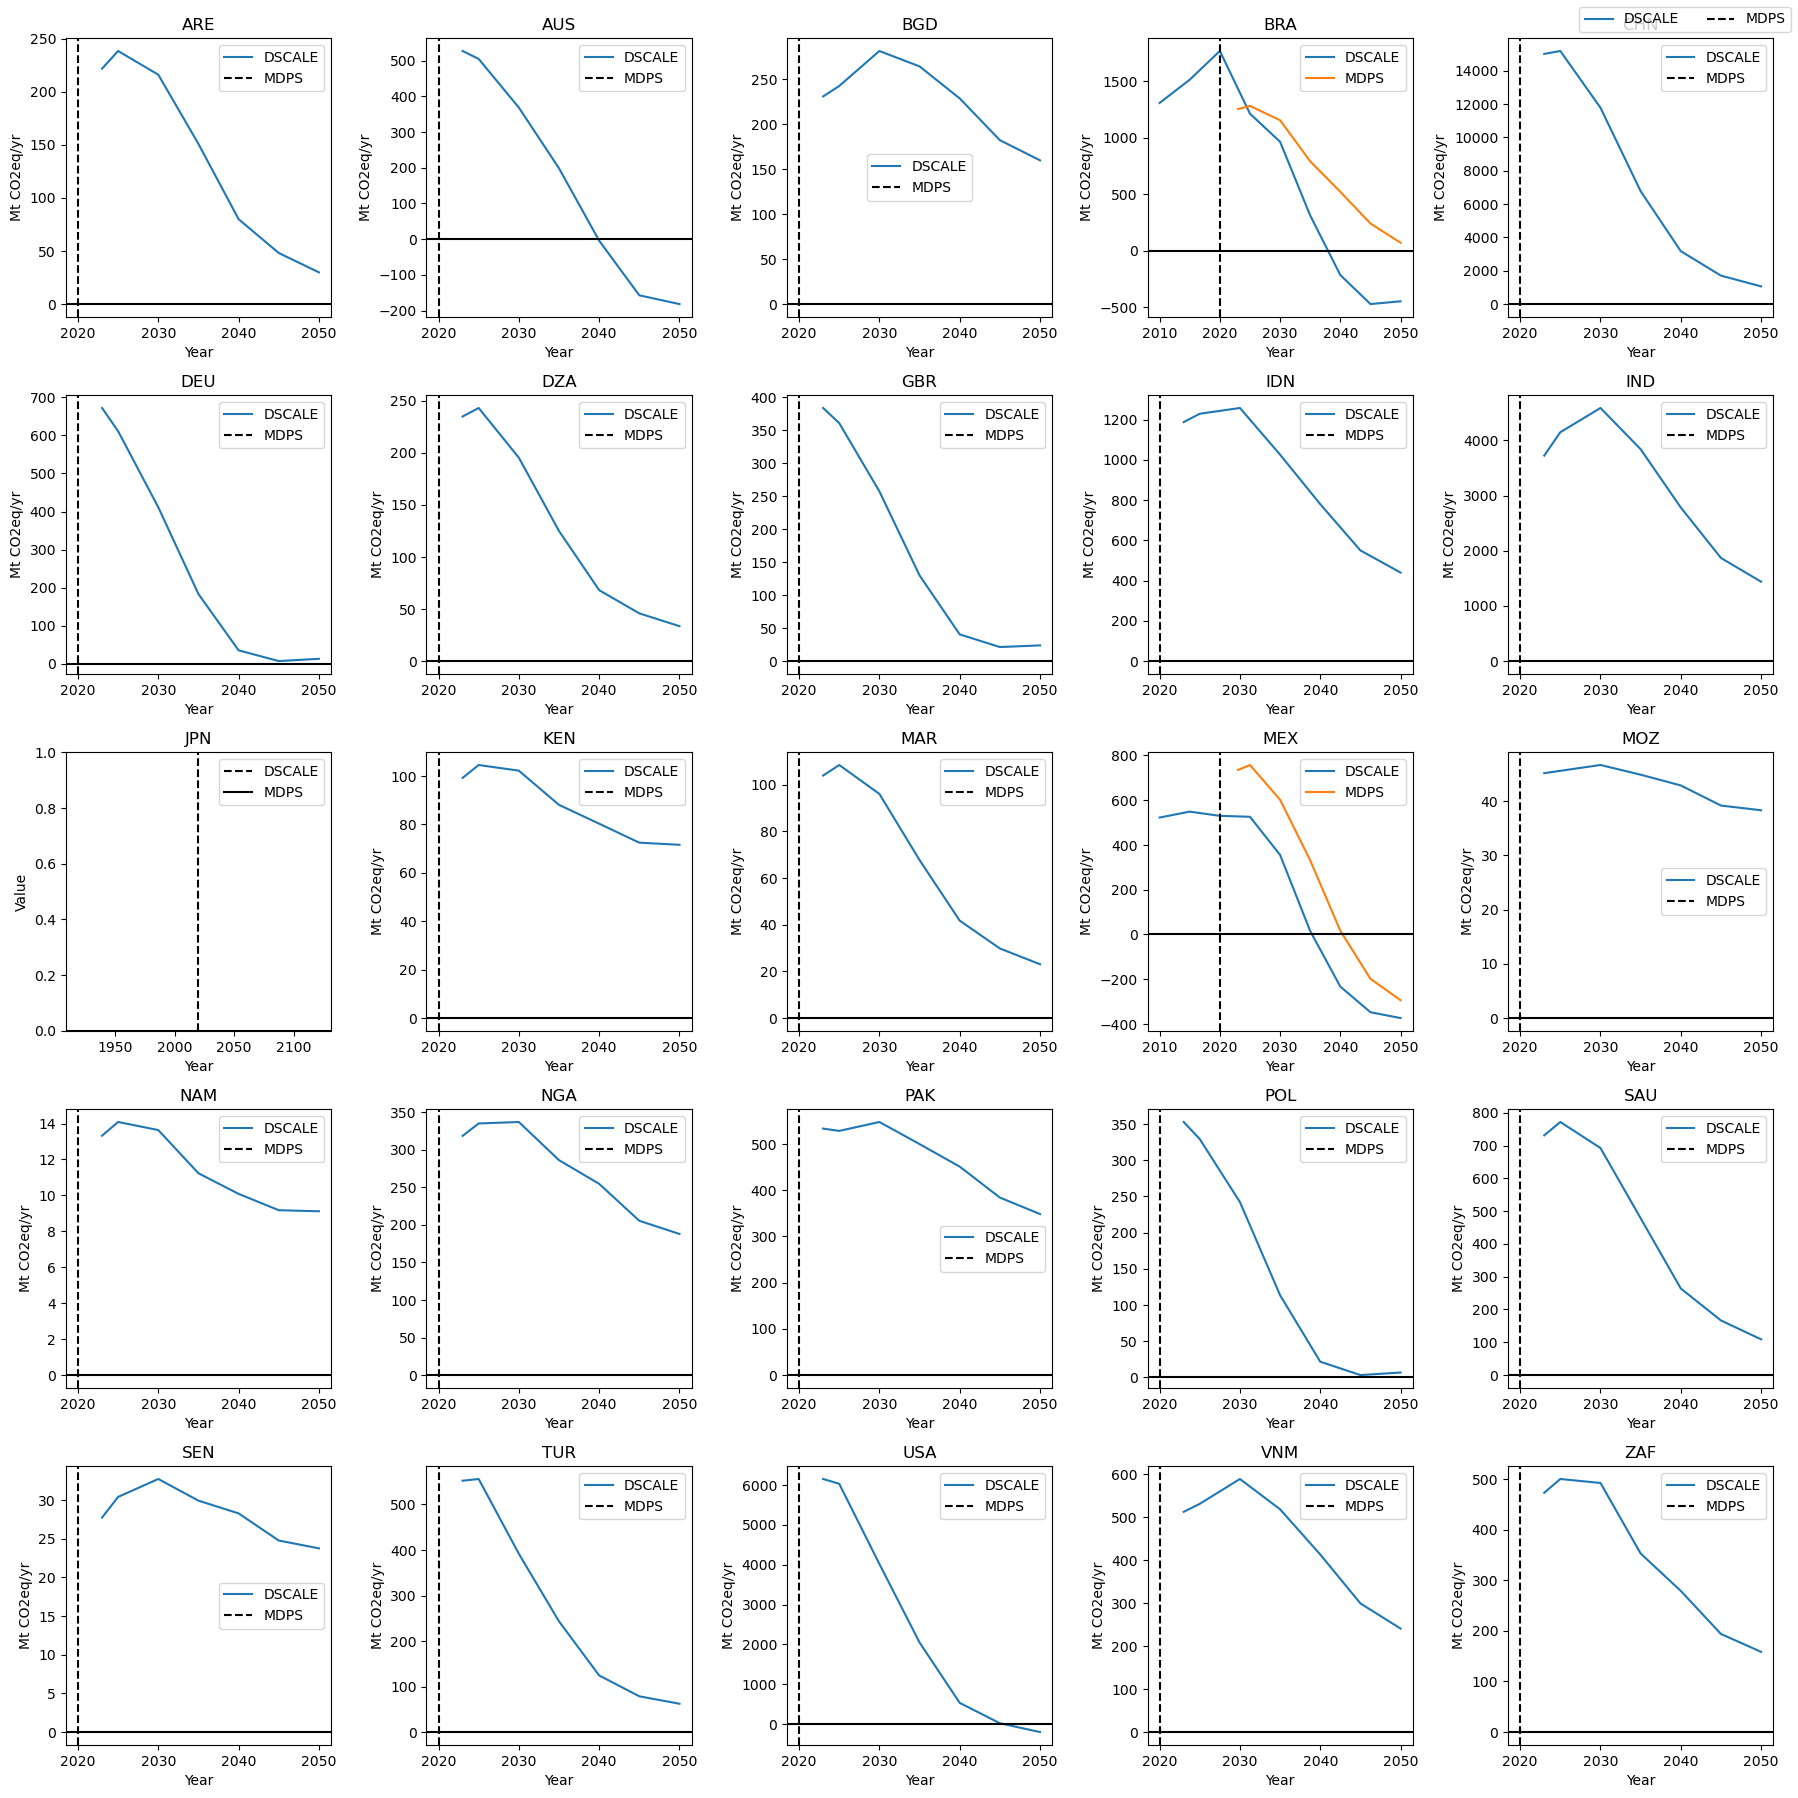

In [47]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
vars = "Emissions|Kyoto Gases (incl. indirect AFOLU)"

for count, ax in enumerate(axes.ravel()[:]):
    dscale_emissions.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable", label="DSCALE")
    mdps_remind.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=vars,year=range(2010,2051)).plot(ax=ax, linestyle="variable", label="MDPS")
    # primap_data.filter(region=IKEA_ISOS[count],variable=vars,year=range(2010,2025)).plot(ax=ax,color='k', linestyle = "variable")
    ax.axvline(x=2020,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend(['DSCALE','MDPS'])


# f.suptitle('Coal and gas power sector transition',fontsize=14,fontweight='bold', y=1)
f.legend(['DSCALE','MDPS'],ncols=2)
plt.tight_layout()